# **DATA GENERATION - TRAINING**
Data generation with GANs

**DATA GENERATION FOR PERFORMANCE EVALUATION - TRAINING**

In [ ]:

"""
Generador de datos sintéticos para celdas solares de perovskita usando una GAN.
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io

# --- 1. Configuración y Parámetros ---

EPOCHS = 1000          # Número de épocas de entrenamiento
BATCH_SIZE = 64         # Tamaño del lote
LR = 0.0002             # Tasa de aprendizaje
LATENT_DIM = 128        # Dimensión del vector de ruido
DATA_DIM = 10           # Número de columnas del dataset
N_SAMPLES_TO_GENERATE = 1501  # Número de nuevas observaciones a generar

# --- 2. Carga y Preprocesamiento de Datos ---

def load_and_preprocess_data():
    """

    """
    print("🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Error: no se subió ningún archivo.")
        return None, None, None

    # Obtener el nombre del primer archivo subido
    filename = list(uploaded.keys())[0]
    print(f"\nCargando datos desde '{filename}'...")
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if df.shape[1] != DATA_DIM:
        print(f"Error: el dataset debe tener {DATA_DIM} columnas, pero tiene {df.shape[1]}.")
        return None, None, None

    column_names = df.columns
    data = df.values.astype(np.float32)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_scaled = scaler.fit_transform(data)

    tensor_data = torch.FloatTensor(data_scaled)
    dataset = TensorDataset(tensor_data)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    print("✅ Datos cargados y normalizados correctamente.")
    return dataloader, scaler, column_names


# --- 3. Definición de la Arquitectura de la GAN ---

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, data_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.model(x)


# --- 4. Bucle de Entrenamiento ---

def train_gan(dataloader):
    generator = Generator(LATENT_DIM, DATA_DIM)
    discriminator = Discriminator(DATA_DIM)

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    print("\n Iniciando entrenamiento de la GAN...")

    for epoch in range(EPOCHS):
        for (real_data,) in dataloader:
            # Entrenar el discriminador
            optimizer_d.zero_grad()
            real_labels = torch.ones(BATCH_SIZE, 1)
            fake_labels = torch.zeros(BATCH_SIZE, 1)

            output_real = discriminator(real_data)
            loss_d_real = criterion(output_real, real_labels)

            noise = torch.randn(BATCH_SIZE, LATENT_DIM)
            fake_data = generator(noise)
            output_fake = discriminator(fake_data.detach())
            loss_d_fake = criterion(output_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()

            # Entrenar el generador
            optimizer_g.zero_grad()
            output_g = discriminator(fake_data)
            loss_g = criterion(output_g, real_labels)
            loss_g.backward()
            optimizer_g.step()

        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] | Pérdida D: {loss_d.item():.4f} | Pérdida G: {loss_g.item():.4f}")

    print("Entrenamiento finalizado.")
    return generator


# --- 5. Generación y Descarga de Datos Sintéticos ---

def generate_and_download_data(generator, scaler, column_names):
    """
    Genera los datos sintéticos y permite descargarlos como CSV desde Colab.
    """
    print(f"\n Generando {N_SAMPLES_TO_GENERATE} nuevas muestras sintéticas...")
    generator.eval()
    noise = torch.randn(N_SAMPLES_TO_GENERATE, LATENT_DIM)

    with torch.no_grad():
        generated_data_scaled = generator(noise).numpy()

    generated_data = scaler.inverse_transform(generated_data_scaled)
    df_generated = pd.DataFrame(generated_data, columns=column_names)

    output_filename = input(" Ingresa el nombre del archivo de salida (por ejemplo: generated_perovskite_data.csv): ")
    if not output_filename.endswith(".csv"):
        output_filename += ".csv"

    df_generated.to_csv(output_filename, index=False)
    print(f"\n✅ Datos generados guardados como '{output_filename}'.")
    print("\nPrimeras 5 filas de los datos generados:")
    print(df_generated.head())

    print("\n⬇️ Descargando archivo...")
    files.download(output_filename)


# --- Script Principal ---

if __name__ == "__main__":
    dataloader, scaler, column_names = load_and_preprocess_data()

    if dataloader is not None:
        trained_generator = train_gan(dataloader)
        generate_and_download_data(trained_generator, scaler, column_names)


🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):


Saving Data_train.csv to Data_train (1).csv

Cargando datos desde 'Data_train (1).csv'...
✅ Datos cargados y normalizados correctamente.

🚀 Iniciando entrenamiento de la GAN...
Época [10/1000] | Pérdida D: 0.6378 | Pérdida G: 1.5112
Época [20/1000] | Pérdida D: 1.7304 | Pérdida G: 0.9008
Época [30/1000] | Pérdida D: 0.9746 | Pérdida G: 1.0098
Época [40/1000] | Pérdida D: 1.2542 | Pérdida G: 0.8664
Época [50/1000] | Pérdida D: 1.2619 | Pérdida G: 0.8036
Época [60/1000] | Pérdida D: 1.2320 | Pérdida G: 0.7840
Época [70/1000] | Pérdida D: 1.3189 | Pérdida G: 0.7412
Época [80/1000] | Pérdida D: 1.3644 | Pérdida G: 0.8041
Época [90/1000] | Pérdida D: 1.3045 | Pérdida G: 0.7905
Época [100/1000] | Pérdida D: 1.3328 | Pérdida G: 0.9310
Época [110/1000] | Pérdida D: 1.2806 | Pérdida G: 0.8389
Época [120/1000] | Pérdida D: 1.2883 | Pérdida G: 0.8666
Época [130/1000] | Pérdida D: 1.2613 | Pérdida G: 0.8322
Época [140/1000] | Pérdida D: 1.3352 | Pérdida G: 0.8031
Época [150/1000] | Pérdida D: 1.26

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**DATA GENERATION FOR DATA AUMENTATION - TRAINING**

In [ ]:

"""
Generador de datos sintéticos para celdas solares de perovskita usando una GAN.
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io

# --- 1. Configuración y Parámetros ---

EPOCHS = 3000          # Número de épocas de entrenamiento
BATCH_SIZE = 64         # Tamaño del lote
LR = 0.0002             # Tasa de aprendizaje
LATENT_DIM = 128        # Dimensión del vector de ruido
DATA_DIM = 10           # Número de columnas del dataset
N_SAMPLES_TO_GENERATE = 3000  # Número de nuevas observaciones a generar

# --- 2. Carga y Preprocesamiento de Datos ---

def load_and_preprocess_data():
    print(" Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Error: no se subió ningún archivo.")
        return None, None, None

    # Obtener el nombre del primer archivo subido
    filename = list(uploaded.keys())[0]
    print(f"\nCargando datos desde '{filename}'...")
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if df.shape[1] != DATA_DIM:
        print(f"Error: el dataset debe tener {DATA_DIM} columnas, pero tiene {df.shape[1]}.")
        return None, None, None

    column_names = df.columns
    data = df.values.astype(np.float32)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_scaled = scaler.fit_transform(data)

    tensor_data = torch.FloatTensor(data_scaled)
    dataset = TensorDataset(tensor_data)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    print(" Datos cargados y normalizados correctamente.")
    return dataloader, scaler, column_names


# --- 3. Definición de la Arquitectura de la GAN ---

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, data_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.model(x)


# --- 4. Bucle de Entrenamiento ---

def train_gan(dataloader):
    generator = Generator(LATENT_DIM, DATA_DIM)
    discriminator = Discriminator(DATA_DIM)

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    print("\n Iniciando entrenamiento de la GAN...")

    for epoch in range(EPOCHS):
        for (real_data,) in dataloader:
            # Entrenar el discriminador
            optimizer_d.zero_grad()
            real_labels = torch.ones(BATCH_SIZE, 1)
            fake_labels = torch.zeros(BATCH_SIZE, 1)

            output_real = discriminator(real_data)
            loss_d_real = criterion(output_real, real_labels)

            noise = torch.randn(BATCH_SIZE, LATENT_DIM)
            fake_data = generator(noise)
            output_fake = discriminator(fake_data.detach())
            loss_d_fake = criterion(output_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()

            # Entrenar el generador
            optimizer_g.zero_grad()
            output_g = discriminator(fake_data)
            loss_g = criterion(output_g, real_labels)
            loss_g.backward()
            optimizer_g.step()

        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] | Pérdida D: {loss_d.item():.4f} | Pérdida G: {loss_g.item():.4f}")

    print(" Entrenamiento finalizado.")
    return generator


# --- 5. Generación y Descarga de Datos Sintéticos ---

def generate_and_download_data(generator, scaler, column_names):
    """
    Genera los datos sintéticos y permite descargarlos como CSV desde Colab.
    """
    print(f"\n🧬 Generando {N_SAMPLES_TO_GENERATE} nuevas muestras sintéticas...")
    generator.eval()
    noise = torch.randn(N_SAMPLES_TO_GENERATE, LATENT_DIM)

    with torch.no_grad():
        generated_data_scaled = generator(noise).numpy()

    generated_data = scaler.inverse_transform(generated_data_scaled)
    df_generated = pd.DataFrame(generated_data, columns=column_names)

    output_filename = input("💾 Ingresa el nombre del archivo de salida (por ejemplo: generated_perovskite_data.csv): ")
    if not output_filename.endswith(".csv"):
        output_filename += ".csv"

    df_generated.to_csv(output_filename, index=False)
    print(f"\n Datos generados guardados como '{output_filename}'.")
    print("\nPrimeras 5 filas de los datos generados:")
    print(df_generated.head())

    print("\n⬇ Descargando archivo...")
    files.download(output_filename)


# --- Script Principal ---

if __name__ == "__main__":
    dataloader, scaler, column_names = load_and_preprocess_data()

    if dataloader is not None:
        trained_generator = train_gan(dataloader)
        generate_and_download_data(trained_generator, scaler, column_names)


🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):


Saving Data_train.csv to Data_train (1).csv

Cargando datos desde 'Data_train (1).csv'...
✅ Datos cargados y normalizados correctamente.

🚀 Iniciando entrenamiento de la GAN...
Época [10/3000] | Pérdida D: 0.8538 | Pérdida G: 1.8784
Época [20/3000] | Pérdida D: 1.1282 | Pérdida G: 0.8961
Época [30/3000] | Pérdida D: 1.3030 | Pérdida G: 0.7944
Época [40/3000] | Pérdida D: 1.2387 | Pérdida G: 0.7521
Época [50/3000] | Pérdida D: 1.3279 | Pérdida G: 0.8680
Época [60/3000] | Pérdida D: 1.1562 | Pérdida G: 1.0517
Época [70/3000] | Pérdida D: 1.2598 | Pérdida G: 0.7986
Época [80/3000] | Pérdida D: 1.2315 | Pérdida G: 0.8420
Época [90/3000] | Pérdida D: 1.1047 | Pérdida G: 0.9351
Época [100/3000] | Pérdida D: 1.2042 | Pérdida G: 0.8697
Época [110/3000] | Pérdida D: 1.2078 | Pérdida G: 0.9079
Época [120/3000] | Pérdida D: 1.2873 | Pérdida G: 0.7542
Época [130/3000] | Pérdida D: 1.1800 | Pérdida G: 0.9136
Época [140/3000] | Pérdida D: 1.2072 | Pérdida G: 1.1052
Época [150/3000] | Pérdida D: 1.25

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **DATA GENERATION - PERFORMANCE EVALUATION**
Comparison of GAN and GMM against real data

=== Análisis Completo: Hellinger, Multi-kernel MMD, Bootstrap y Permutación ===
🔼 Sube los tres archivos CSV: primero el real, luego el sintético GMM y luego el sintético GAN.


Saving Data_train.csv to Data_train.csv
Saving Data_samples.csv to Data_samples (2).csv
Saving generated_perovskite_GAN3.csv to generated_perovskite_GAN3 (2).csv

📂 Archivos:
 - Real: Data_train.csv
 - GMM:  Data_samples (2).csv
 - GAN:  generated_perovskite_GAN3 (2).csv

Introduce el número de columnas a usar (Enter para 10): 

📏 Validando Hellinger con múltiples configuraciones (BINS y PCA)...
Bins   | PCA    | Hellinger (GMM)    | Hellinger (GAN)   
-------------------------------------------------------
5      | 2      | 0.0887             | 0.1548            
5      | 4      | 0.3012             | 0.2012            
5      | 6      | 0.3522             | 0.2740            
8      | 2      | 0.1303             | 0.1731            
8      | 4      | 0.4123             | 0.2170            
8      | 6      | 0.4770             | 0.3028            
12     | 2      | 0.1859             | 0.1927            
12     | 4      | 0.4534             | 0.2820            
12     | 6      | 0.592

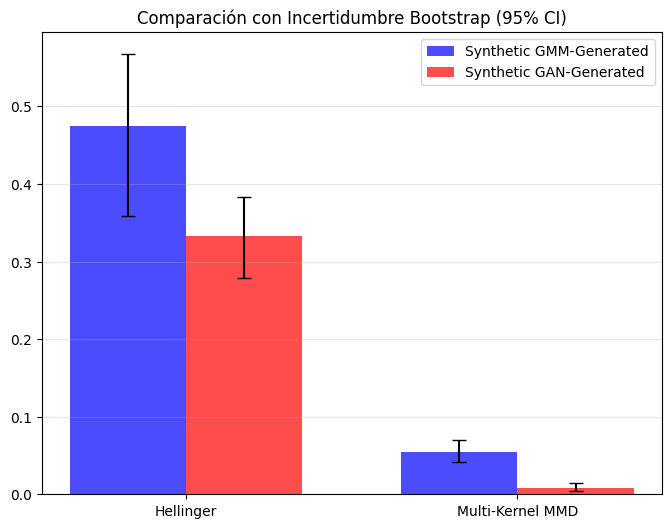


✅ Ejecución finalizada con éxito.


In [ ]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from google.colab import files

# ----------------- Configuración -----------------
RANDOM_STATE = 42
TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000
BANDWIDTH_FACTOR = None
DEFAULT_N_EXPECTED_COLS = 10

OUT_DIM1_PNG = "kde_tsne_dim1_three.png"
OUT_DIM2_PNG = "kde_tsne_dim2_three.png"
OUT_HELLINGER_PNG = "hellinger_comparison.png"
OUT_MMD_PNG = "mmd_comparison.png"

# Params para Hellinger Validation
BINS_LIST = [5, 8, 12]
PCA_DIMS_LIST = [2, 4, 6]
MAX_HIST_DIMS = 6

# Params para MMD, Bootstrap y Permutación
BOOTSTRAP_ITERS = 50       # Iteraciones para calcular incertidumbre
MMD_SUBSAMPLE = 500        # Datos por muestra de bootstrap y test (eficiencia)
N_PERMUTATIONS = 1000      # Número de permutaciones para el test de hipótesis
MULTI_KERNEL_FACTORS = [0.1, 0.5, 1.0, 2.0, 10.0] # Multiplicadores para el ancho de banda

# Etiquetas
LABEL_REAL = "Real Data"
LABEL_GMM  = "Synthetic GMM-Generated"
LABEL_GAN  = "Synthetic GAN-Generated"
# -------------------------------------------------

# ----------------- 1. Carga de Datos -----------------
def upload_three_files_prompt():
    print("🔼 Sube los tres archivos CSV: primero el real, luego el sintético GMM y luego el sintético GAN.")
    uploaded = files.upload()
    while len(uploaded) < 3:
        print(f"Se detectó {len(uploaded)} archivo(s). Por favor sube los otros archivos (total 3).")
        more = files.upload()
        uploaded.update(more)
    return uploaded

def read_three_csvs_from_uploaded(uploaded):
    keys = list(uploaded.keys())
    fname_real, fname_gmm, fname_gan = keys[0], keys[1], keys[2]
    df_real = pd.read_csv(io.BytesIO(uploaded[fname_real]))
    df_gmm  = pd.read_csv(io.BytesIO(uploaded[fname_gmm]))
    df_gan  = pd.read_csv(io.BytesIO(uploaded[fname_gan]))
    return df_real, df_gmm, df_gan, fname_real, fname_gmm, fname_gan

# ----------------- 2. Funciones de Limpieza -----------------
def dropna_and_report(X, label):
    mask = ~np.isnan(X).any(axis=1)
    removed = X.shape[0] - mask.sum()
    if removed > 0:
        print(f"⚠️ Advertencia: se eliminaron {removed} filas con NaN en {label}.")
    return X[mask]

def ensure_numeric_matrix(df, n_cols):
    if df.shape[1] < n_cols:
        raise ValueError(f"Se esperaban {n_cols} columnas, pero hay {df.shape[1]}.")
    return df.iloc[:, :n_cols].values.astype(float)

def adjust_perplexity(perplexity, n_samples):
    max_allowed = max(5, int(np.floor(n_samples / 3) - 1))
    return min(perplexity, max_allowed)

# ----------------- 3. Funciones Hellinger -----------------
def hellinger_from_densities(p, q, dx):
    p = np.maximum(p, 0.0)
    q = np.maximum(q, 0.0)
    h = (1.0 / np.sqrt(2.0)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2) * dx)
    return float(h)

def hellinger_histogramdd(a, b, bins=8, use_pca_dims=4):
    a, b = np.asarray(a), np.asarray(b)
    d = a.shape[1]

    if d > MAX_HIST_DIMS or use_pca_dims < d:
        scaler = StandardScaler()
        combo = np.vstack([a, b])
        combo_s = scaler.fit_transform(combo)
        pca = PCA(n_components=min(use_pca_dims, d), random_state=RANDOM_STATE)
        combo_p = pca.fit_transform(combo_s)
        a2 = combo_p[:a.shape[0], :]
        b2 = combo_p[a.shape[0]:, :]
    else:
        a2, b2 = a.copy(), b.copy()

    mins = np.minimum(a2.min(axis=0), b2.min(axis=0))
    maxs = np.maximum(a2.max(axis=0), b2.max(axis=0))
    ranges = [(mins[i], maxs[i]) for i in range(a2.shape[1])]

    H_hist, _ = np.histogramdd(a2, bins=bins, range=ranges)
    G_hist, _ = np.histogramdd(b2, bins=bins, range=ranges)

    H_hist = H_hist.astype(float) / (np.sum(H_hist) + 1e-10)
    G_hist = G_hist.astype(float) / (np.sum(G_hist) + 1e-10)

    return hellinger_from_densities(H_hist.ravel(), G_hist.ravel(), dx=1.0)

# ----------------- 4. Funciones Multi-Kernel MMD y Pruebas -----------------
def compute_base_gamma(X_list, subsample=1000, random_state=42):
    """Calcula el gamma base usando la heurística de la mediana sobre datos combinados."""
    np.random.seed(random_state)
    X_comb = np.vstack(X_list)
    if X_comb.shape[0] > subsample:
        idx = np.random.choice(X_comb.shape[0], subsample, replace=False)
        X_comb = X_comb[idx]

    D = pairwise_distances(X_comb, metric='euclidean')
    dvals = D[np.triu_indices_from(D, k=1)]
    med = np.median(dvals)
    if med <= 0: med = 1.0
    return 1.0 / (2.0 * (med**2) + 1e-8)

def mmd_multi_kernel_statistic(X, Y, gammas):
    """Calcula el MMD^2 empírico usando una suma de kernels RBF (Multi-kernel)."""
    n_x, n_y = X.shape[0], Y.shape[0]
    combined = np.vstack([X, Y])

    K_full = np.zeros((combined.shape[0], combined.shape[0]))
    for g in gammas:
        K_full += rbf_kernel(combined, combined, gamma=g)
    K_full /= len(gammas) # Promedio de los kernels

    Kxx = K_full[:n_x, :n_x]
    Kyy = K_full[n_x:, n_x:]
    Kxy = K_full[:n_x, n_x:]

    return Kxx.sum()/(n_x*n_x) + Kyy.sum()/(n_y*n_y) - 2*Kxy.sum()/(n_x*n_y)

def fast_multikernel_permutation_test(X, Y, gammas, n_perm=1000, subsample=500, random_state=RANDOM_STATE):
    """Prueba de hipótesis de permutación optimizada para Multi-Kernel MMD."""
    np.random.seed(random_state)

    # Submuestreo para eficiencia
    if X.shape[0] > subsample:
        X = X[np.random.choice(X.shape[0], subsample, replace=False)]
    if Y.shape[0] > subsample:
        Y = Y[np.random.choice(Y.shape[0], subsample, replace=False)]

    n_x, n_y = X.shape[0], Y.shape[0]
    n_total = n_x + n_y
    combined = np.vstack([X, Y])

    # Precomputar Matriz Multi-Kernel completa
    K_full = np.zeros((n_total, n_total))
    for g in gammas:
        K_full += rbf_kernel(combined, combined, gamma=g)
    K_full /= len(gammas)

    # Calcular MMD Observado
    Kxx = K_full[:n_x, :n_x]
    Kyy = K_full[n_x:, n_x:]
    Kxy = K_full[:n_x, n_x:]
    mmd_obs = Kxx.sum()/(n_x**2) + Kyy.sum()/(n_y**2) - 2*Kxy.sum()/(n_x*n_y)

    # Ejecutar Permutaciones
    count_greater = 0
    idx = np.arange(n_total)

    for _ in range(n_perm):
        np.random.shuffle(idx)
        idx_x = idx[:n_x]
        idx_y = idx[n_x:]

        Kxx_p = K_full[np.ix_(idx_x, idx_x)]
        Kyy_p = K_full[np.ix_(idx_y, idx_y)]
        Kxy_p = K_full[np.ix_(idx_x, idx_y)]

        mmd_perm = Kxx_p.sum()/(n_x**2) + Kyy_p.sum()/(n_y**2) - 2*Kxy_p.sum()/(n_x*n_y)

        if mmd_perm >= mmd_obs:
            count_greater += 1

    p_val = (count_greater + 1) / (n_perm + 1)
    return float(mmd_obs), float(p_val)

# ----------------- 5. Función de Bootstrap -----------------
def get_bootstrap_ci(X, Y, metric_fn, n_boot=50, subsample=500, **kwargs):
    """Calcula la métrica sobre muestras bootstrap para estimar incertidumbre."""
    np.random.seed(RANDOM_STATE)
    vals = []
    n_x, n_y = X.shape[0], Y.shape[0]

    for _ in range(n_boot):
        # Muestreo con reemplazo
        idx_x = np.random.choice(n_x, size=min(n_x, subsample), replace=True)
        idx_y = np.random.choice(n_y, size=min(n_y, subsample), replace=True)

        val = metric_fn(X[idx_x], Y[idx_y], **kwargs)
        vals.append(val)

    return np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

# =============================================================================
#                                EJECUCIÓN PRINCIPAL
# =============================================================================
print("=== Análisis Completo: Hellinger, Multi-kernel MMD, Bootstrap y Permutación ===")

# 1. Cargar Archivos
uploaded = upload_three_files_prompt()
df_real, df_gmm, df_gan, fname_real, fname_gmm, fname_gan = read_three_csvs_from_uploaded(uploaded)

print(f"\n📂 Archivos:\n - Real: {fname_real}\n - GMM:  {fname_gmm}\n - GAN:  {fname_gan}")

# 2. Selección de Columnas
try:
    user_input = input(f"\nIntroduce el número de columnas a usar (Enter para {DEFAULT_N_EXPECTED_COLS}): ").strip()
    n_cols = int(user_input) if user_input else DEFAULT_N_EXPECTED_COLS
except:
    n_cols = DEFAULT_N_EXPECTED_COLS

X_real = dropna_and_report(ensure_numeric_matrix(df_real, n_cols), LABEL_REAL)
X_gmm  = dropna_and_report(ensure_numeric_matrix(df_gmm, n_cols), LABEL_GMM)
X_gan  = dropna_and_report(ensure_numeric_matrix(df_gan, n_cols), LABEL_GAN)

# 3. Validación Exhaustiva de Hellinger
print("\n📏 Validando Hellinger con múltiples configuraciones (BINS y PCA)...")
print(f"{'Bins':<6} | {'PCA':<6} | {'Hellinger (GMM)':<18} | {'Hellinger (GAN)':<18}")
print("-" * 55)
for b in BINS_LIST:
    for p in PCA_DIMS_LIST:
        h_gmm = hellinger_histogramdd(X_real, X_gmm, bins=b, use_pca_dims=p)
        h_gan = hellinger_histogramdd(X_real, X_gan, bins=b, use_pca_dims=p)
        print(f"{b:<6} | {p:<6} | {h_gmm:<18.4f} | {h_gan:<18.4f}")

# Utilizar la configuración intermedia para el gráfico resumen (ej. bins=8, pca=4)
default_bins, default_pca = 8, 4
print(f"\nUsando Bins={default_bins}, PCA={default_pca} para análisis Bootstrap...")

# 4. Cálculo de Incertidumbre vía Bootstrap (Hellinger)
print("⏳ Calculando Incertidumbre Bootstrap para Hellinger...")
h_mean_gmm, h_low_gmm, h_high_gmm = get_bootstrap_ci(
    X_real, X_gmm, hellinger_histogramdd, n_boot=BOOTSTRAP_ITERS, subsample=MMD_SUBSAMPLE,
    bins=default_bins, use_pca_dims=default_pca
)
h_mean_gan, h_low_gan, h_high_gan = get_bootstrap_ci(
    X_real, X_gan, hellinger_histogramdd, n_boot=BOOTSTRAP_ITERS, subsample=MMD_SUBSAMPLE,
    bins=default_bins, use_pca_dims=default_pca
)

# 5. Multi-Kernel MMD y Bootstrap
print("\n🎲 Configurando Multi-Kernel MMD...")
base_gamma = compute_base_gamma([X_real, X_gmm, X_gan], subsample=2000)
gammas = [base_gamma * f for f in MULTI_KERNEL_FACTORS]
print(f"   -> Gammas a utilizar: {[round(g, 4) for g in gammas]}")

print("⏳ Calculando Incertidumbre Bootstrap para MMD...")
m_mean_gmm, m_low_gmm, m_high_gmm = get_bootstrap_ci(
    X_real, X_gmm, mmd_multi_kernel_statistic, n_boot=BOOTSTRAP_ITERS, subsample=MMD_SUBSAMPLE, gammas=gammas
)
m_mean_gan, m_low_gan, m_high_gan = get_bootstrap_ci(
    X_real, X_gan, mmd_multi_kernel_statistic, n_boot=BOOTSTRAP_ITERS, subsample=MMD_SUBSAMPLE, gammas=gammas
)

# 6. Prueba de Hipótesis (Permutación)
print(f"\n🧪 Ejecutando Prueba de Hipótesis de Permutación (N={N_PERMUTATIONS})...")
stat_gmm, pval_gmm = fast_multikernel_permutation_test(X_real, X_gmm, gammas, n_perm=N_PERMUTATIONS, subsample=MMD_SUBSAMPLE)
stat_gan, pval_gan = fast_multikernel_permutation_test(X_real, X_gan, gammas, n_perm=N_PERMUTATIONS, subsample=MMD_SUBSAMPLE)

print("-" * 60)
print("📊 RESULTADOS FINALES:")
print(f" HELLINGER (Media ± Intervalo de Confianza 95%):")
print(f"  >> Real vs GMM: {h_mean_gmm:.4f}  (95% CI: [{h_low_gmm:.4f}, {h_high_gmm:.4f}])")
print(f"  >> Real vs GAN: {h_mean_gan:.4f}  (95% CI: [{h_low_gan:.4f}, {h_high_gan:.4f}])")
print(f"\n MULTI-KERNEL MMD (Media ± Intervalo de Confianza 95%):")
print(f"  >> Real vs GMM: {m_mean_gmm:.6f}  (95% CI: [{m_low_gmm:.6f}, {m_high_gmm:.6f}])")
print(f"  >> Real vs GAN: {m_mean_gan:.6f}  (95% CI: [{m_low_gan:.6f}, {m_high_gan:.6f}])")
print(f"\n PRUEBA DE HOMOGENEIDAD (Permutaciones):")
print(f"  >> Real vs GMM: Estadístico = {stat_gmm:.6f} | p-value = {pval_gmm:.4f}")
print(f"  >> Real vs GAN: Estadístico = {stat_gan:.6f} | p-value = {pval_gan:.4f}")
print("-" * 60)

# 7. Gráfico de Barras con Barras de Error
metrics = ['Hellinger', 'Multi-Kernel MMD']
x = np.arange(len(metrics))
width = 0.35

vals_gmm = [h_mean_gmm, m_mean_gmm]
err_gmm_lower = [h_mean_gmm - h_low_gmm, m_mean_gmm - m_low_gmm]
err_gmm_upper = [h_high_gmm - h_mean_gmm, m_high_gmm - m_mean_gmm]
err_gmm = [err_gmm_lower, err_gmm_upper]

vals_gan = [h_mean_gan, m_mean_gan]
err_gan_lower = [h_mean_gan - h_low_gan, m_mean_gan - m_low_gan]
err_gan_upper = [h_high_gan - h_mean_gan, m_high_gan - m_mean_gan]
err_gan = [err_gan_lower, err_gan_upper]

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, vals_gmm, width, yerr=err_gmm, label=LABEL_GMM, color='blue', alpha=0.7, capsize=5)
rects2 = ax.bar(x + width/2, vals_gan, width, yerr=err_gan, label=LABEL_GAN, color='red', alpha=0.7, capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Comparación con Incertidumbre Bootstrap (95% CI)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.savefig(OUT_MMD_PNG, dpi=300)
plt.show()

print("\n✅ Ejecución finalizada con éxito.")

# **DIVERSITY, MEMORIZATION, AND CORRELATION PRESERVATION.**

=== Evaluación de Diversidad, Memorización y Correlación ===

📂 Datos cargados y alineados:
 - Real ('Data_train.csv'): (4201, 10)
 - Sintético ('generated_perovskite_GAN3.csv'): (1501, 10)

⏳ Calculando 1-NN Adversarial Accuracy...
 📊 1-NN Adversarial Accuracy: 0.7788
    (Interpretación: ~0.50 es ideal/indistinguible. >0.50 son diferentes. <<0.50 es sobreajuste/copia)

⏳ Calculando distancias al registro real más cercano (DCR)...
 🔍 Copias Exactas Encontradas: 0 de 1501 (0.00%)
 ✅ EXCELENTE: No se detectaron copias exactas de los datos de entrenamiento.
 📏 Distancia mínima promedio (DCR Media): 0.2641

⏳ Calculando preservación de correlación por pares...


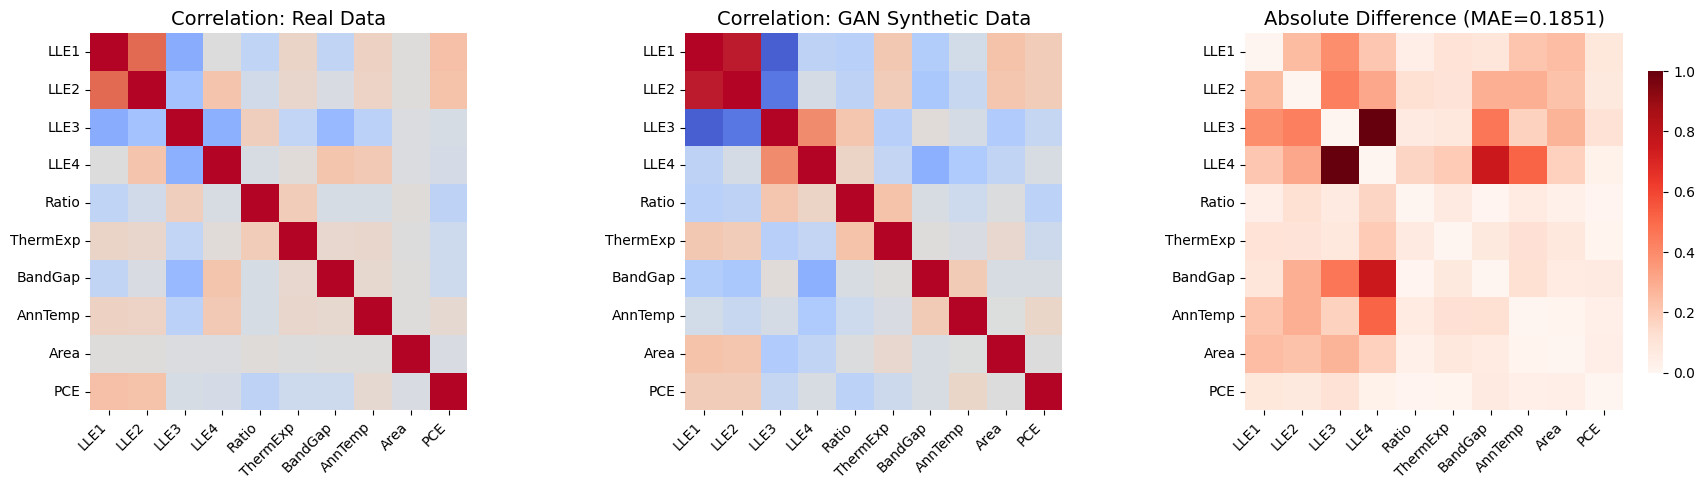

✅ Se generaron exitosamente las 3 imágenes separadas en formato PNG: corr_a_real.png, corr_b_synth.png, corr_c_diff.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ----------------- Configuración -----------------
FILE_REAL = "Data_train.csv"
FILE_SYNTH = "generated_perovskite_GAN3.csv"
RANDOM_STATE = 42
CV_FOLDS = 5 # Folds para evaluar 1-NN Adversarial Accuracy

# -------------------------------------------------

print("=== Evaluación de Diversidad, Memorización y Correlación ===")

# 1. Cargar Datos
if not os.path.exists(FILE_REAL) or not os.path.exists(FILE_SYNTH):
    raise FileNotFoundError(f"⚠️ Asegúrate de subir '{FILE_REAL}' y '{FILE_SYNTH}' al entorno de Colab.")

df_real = pd.read_csv(FILE_REAL)
df_synth = pd.read_csv(FILE_SYNTH)

# Quedarnos solo con columnas numéricas y eliminar NaNs
df_real = df_real.select_dtypes(include=[np.number]).dropna()
df_synth = df_synth.select_dtypes(include=[np.number]).dropna()

# Alinear columnas (usar la intersección de columnas para que coincidan)
common_cols = list(set(df_real.columns).intersection(set(df_synth.columns)))
df_real = df_real[common_cols]
df_synth = df_synth[common_cols]

print(f"\n📂 Datos cargados y alineados:")
print(f" - Real ('{FILE_REAL}'): {df_real.shape}")
print(f" - Sintético ('{FILE_SYNTH}'): {df_synth.shape}")

X_real = df_real.values
X_synth = df_synth.values

# Escalar los datos (Crucial para medidas basadas en distancia como 1-NN y DCR)
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)
X_synth_scaled = scaler.transform(X_synth)


# =====================================================================
# 1. 1-NN Adversarial Accuracy (Prueba de dos muestras)
# =====================================================================
print("\n⏳ Calculando 1-NN Adversarial Accuracy...")
# Etiquetar: Real = 0, Sintético = 1
y_real = np.zeros(X_real_scaled.shape[0])
y_synth = np.ones(X_synth_scaled.shape[0])

X_combined = np.vstack((X_real_scaled, X_synth_scaled))
y_combined = np.hstack((y_real, y_synth))

knn = KNeighborsClassifier(n_neighbors=1)
# Usamos validación cruzada para mayor robustez
cv_scores = cross_val_score(knn, X_combined, y_combined, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1)
nn_accuracy = np.mean(cv_scores)

print(f" 📊 1-NN Adversarial Accuracy: {nn_accuracy:.4f}")
print("    (Interpretación: ~0.50 es ideal/indistinguible. >0.50 son diferentes. <<0.50 es sobreajuste/copia)")


# =====================================================================
# 2. DCR (Distance to Closest Record) y Verificación de Copias
# =====================================================================
print("\n⏳ Calculando distancias al registro real más cercano (DCR)...")
nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
nn.fit(X_real_scaled)

# Distancia de cada punto sintético a su vecino real más cercano
distances, indices = nn.kneighbors(X_synth_scaled)
distances = distances.flatten()

# Detección de copias exactas (Tolerancia muy pequeña para error de coma flotante)
tolerance = 1e-6
exact_copies = np.sum(distances < tolerance)
copy_percentage = (exact_copies / len(distances)) * 100

print(f" 🔍 Copias Exactas Encontradas: {exact_copies} de {len(distances)} ({copy_percentage:.2f}%)")
if exact_copies > 0:
    print(f" ⚠️ ALERTA: La GAN está memorizando y generando {exact_copies} registros idénticos a los de entrenamiento.")
else:
    print(" ✅ EXCELENTE: No se detectaron copias exactas de los datos de entrenamiento.")

print(f" 📏 Distancia mínima promedio (DCR Media): {np.mean(distances):.4f}")


# ---------------------------------------------------------------------
# ---------------------------------------------------------------------
# 3. Preservación de Correlación por Pares (NOMBRES CORTOS PARA PAPER)
# ---------------------------------------------------------------------
# Diccionario mapeando de los números originales a los nombres CORTOS
rename_dict_short = {
    '0': 'LLE1',
    '1': 'LLE2',
    '2': 'LLE3',
    '3': 'LLE4',
    '4': 'Ratio',
    '5': 'ThermExp',
    '6': 'BandGap',
    '7': 'AnnTemp',
    '8': 'Area',
    'JV_default_PCE': 'PCE'
}

# (Por si las columnas originales son enteros y no strings)
rename_dict_short.update({int(k): v for k, v in rename_dict_short.items() if k.isdigit()})

# Renombrar
df_real_short = df_real.rename(columns=rename_dict_short)
df_synth_short = df_synth.rename(columns=rename_dict_short)

# El orden deseado pero con los nombres cortos
ordered_cols_short = ['LLE1', 'LLE2', 'LLE3', 'LLE4', 'Ratio', 'ThermExp', 'BandGap', 'AnnTemp', 'Area', 'PCE']

df_real_ordered = df_real_short[ordered_cols_short]
df_synth_ordered = df_synth_short[ordered_cols_short]

print("\n⏳ Calculando preservación de correlación por pares...")
corr_real = df_real_ordered.corr()
corr_synth = df_synth_ordered.corr()

mask = np.triu(np.ones_like(corr_real, dtype=bool), k=1)
mae_corr = np.mean(np.abs(corr_real.values[mask] - corr_synth.values[mask]))

# 5. Graficar Mapas de Calor de Correlación
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Tamaño más compacto al tener nombres cortos

sns.heatmap(corr_real, ax=axes[0], cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar=False, xticklabels=True, yticklabels=True)
axes[0].set_title("Correlation: Real Data", fontsize=14)

sns.heatmap(corr_synth, ax=axes[1], cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar=False, xticklabels=True, yticklabels=True)
axes[1].set_title("Correlation: GAN Synthetic Data", fontsize=14)

sns.heatmap(np.abs(corr_real - corr_synth), ax=axes[2], cmap="Reds", vmin=0, vmax=1,
            square=True, cbar_kws={"shrink": .8}, xticklabels=True, yticklabels=True)
axes[2].set_title(f"Absolute Difference (MAE={mae_corr:.4f})", fontsize=14)

# Rotar 45 grados las x para que quede estilizado
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("correlation_paper_ready.pdf", dpi=300, bbox_inches='tight')
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# (Asumiendo que ya tienes calculados corr_real, corr_synth y mae_corr
# con los nombres cortos del paso anterior)

# Configuración general de fuente
plt.rcParams.update({'font.size': 10})

# --- IMAGEN A: Datos Reales ---
plt.figure(figsize=(6, 5))
sns.heatmap(corr_real, cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar=True, xticklabels=True, yticklabels=True)
# plt.title("Correlation: Real Data") # Opcional: LaTeX ya pondrá el título "(a) Real Data"
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("corr_a_real.png", dpi=300, bbox_inches='tight')
plt.close()

# --- IMAGEN B: Datos Sintéticos ---
plt.figure(figsize=(6, 5))
sns.heatmap(corr_synth, cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar=True, xticklabels=True, yticklabels=True)
# plt.title("Correlation: GAN Synthetic Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("corr_b_synth.png", dpi=300, bbox_inches='tight')
plt.close()

# --- IMAGEN C: Diferencia Absoluta ---
plt.figure(figsize=(6, 5))
corr_diff = np.abs(corr_real - corr_synth)
sns.heatmap(corr_diff, cmap="Reds", vmin=0, vmax=1, square=True,
            cbar=True, xticklabels=True, yticklabels=True)
# plt.title(f"Absolute Difference (MAE={mae_corr:.4f})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("corr_c_diff.png", dpi=300, bbox_inches='tight')
plt.close()

print("✅ Se generaron exitosamente las 3 imágenes separadas en formato PNG: corr_a_real.png, corr_b_synth.png, corr_c_diff.png")

# **DATA AUGMENTATION ON REGRESSION**
Comparison of XGBOOST Models (with and without data augmentation)

In [ ]:
import pandas as pd

# ==============================================================================
# CONFIGURACIÓN
# ==============================================================================
# Cambia este número para obtener una muestra aleatoria diferente cada vez
SEMILLA_ALEATORIA = 25

# Nombres de los archivos
archivo_entrada = 'full_generated_data.csv'
archivo_salida = 'Data_samples2.csv'
cantidad_datos = 3000

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
print(f"Cargando el archivo '{archivo_entrada}'...")
try:
    # 1. Cargar el dataset completo
    df_full = pd.read_csv(archivo_entrada)
    print(f"Total de datos cargados: {len(df_full)}")

    # 2. Extraer la muestra aleatoria
    print(f"Extrayendo una muestra de {cantidad_datos} datos (Semilla: {SEMILLA_ALEATORIA})...")
    df_muestra = df_full.sample(n=cantidad_datos, random_state=SEMILLA_ALEATORIA)

    # 3. Guardar la muestra en un nuevo archivo
    df_muestra.to_csv(archivo_salida, index=False)
    print(f"¡Éxito! La muestra se ha guardado como '{archivo_salida}'.")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_entrada}'. Asegúrate de que esté subido a tu entorno de Colab.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Cargando el archivo 'full_generated_data.csv'...
Total de datos cargados: 18000
Extrayendo una muestra de 3000 datos (Semilla: 25)...
¡Éxito! La muestra se ha guardado como 'Data_samples2.csv'.



[Modelo 1 (Original)] Iniciando modelo...
[Modelo 1 (Original)] Completado. Promedio R2: 0.4566 | Mejor R2 (Fold 5): 0.5053

[Modelo 2 (Con GAN)] Iniciando modelo...
[Modelo 2 (Con GAN)] Completado. Promedio R2: 0.5065 | Mejor R2 (Fold 4): 0.5375

[Modelo 3 (Con GMM)] Iniciando modelo...
[Modelo 3 (Con GMM)] Completado. Promedio R2: 0.4030 | Mejor R2 (Fold 3): 0.4209

RESUMEN COMPARATIVO DE MÉTRICAS
          Métrica  Modelo 1 (Original)  Modelo 2 (GAN)  Modelo 3 (GMM)
    R2 (Promedio)             0.456626        0.506458        0.402963
  RMSE (Promedio)             2.064149        1.911983        2.168954
  MAPE (Promedio)             0.116219        0.105813        0.121546
  R2 (Mejor Fold)             0.505295        0.537510        0.420917
RMSE (Mejor Fold)             2.003001        1.894127        2.162731
MAPE (Mejor Fold)             0.115883        0.105115        0.121652


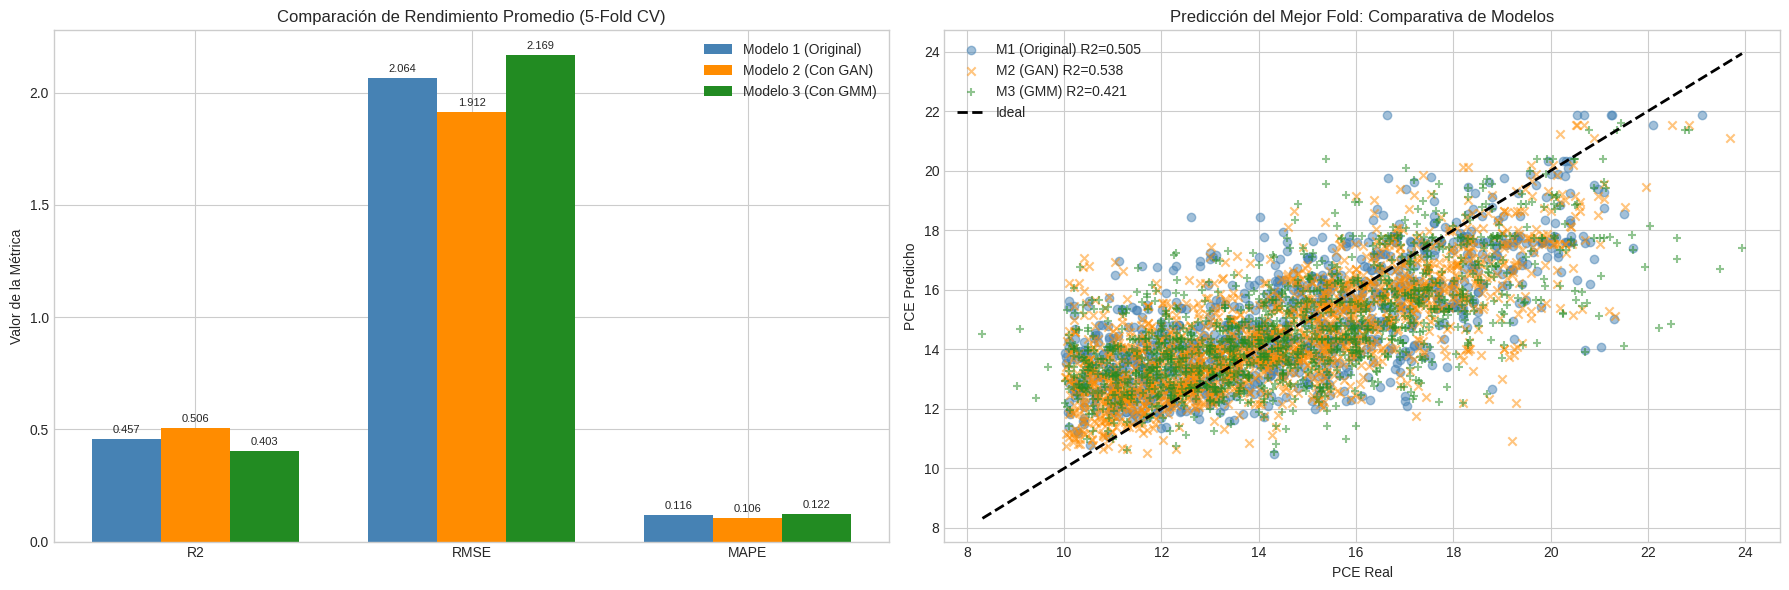


Proceso finalizado con éxito.


In [ ]:
# ==============================================================================
# SCRIPT DE ENTRENAMIENTO Y COMPARACIÓN DE MODELOS XGBOOST
# (ORIGINAL vs GAN vs GMM)
# ==============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import joblib
import matplotlib.pyplot as plt
import os

# Configuración de estilo para gráficas formales
plt.style.use('seaborn-v0_8-whitegrid')

# ==============================================================================
# DEFINICIÓN DE PARÁMETROS DEL MODELO (Idénticos a la referencia)
# ==============================================================================
XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 1000,
    'max_depth': 9,
    'learning_rate': 0.01,
    'subsample': 0.6,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'n_jobs': -1,
    'random_state': 42
}

N_FOLDS = 5

# ==============================================================================
# FUNCIÓN AUXILIAR: ENTRENAMIENTO Y EVALUACIÓN MEDIANTE K-FOLD
# ==============================================================================
def ejecutar_kfold_xgboost(nombre_modelo, df_datos, params, n_folds=10):
    """
    Ejecuta validación cruzada K-Fold sobre un DataFrame dado.
    Retorna métricas promedio, métricas del mejor fold y el mejor modelo.
    """
    print(f"\n[{nombre_modelo}] Iniciando modelo...")

    # Separar X e y (Asumiendo que la variable objetivo es la última columna)
    X = df_datos.iloc[:, :-1].values
    y = df_datos.iloc[:, -1].values

    # Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Inicialización de KFold
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    # Almacenamiento de métricas
    resultados_r2 = []
    resultados_rmse = []
    resultados_mape = []

    best_r2 = -float('inf')
    best_model_obj = None
    best_fold_idx = -1
    best_y_test = None
    best_y_pred = None
    best_scaler = scaler # Guardamos el scaler ajustado a todos los datos para consistencia

    fold = 1
    for train_index, test_index in kf.split(X_scaled):
        # Separar datos
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Instanciar Modelo
        model = xgb.XGBRegressor(**params)

        # Entrenar
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        # Predecir
        y_pred = model.predict(X_test)

        # Calcular Métricas
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)

        resultados_r2.append(r2)
        resultados_rmse.append(rmse)
        resultados_mape.append(mape)

        # Verificar si es el mejor fold
        if r2 > best_r2:
            best_r2 = r2
            best_model_obj = model
            best_fold_idx = fold
            best_y_test = y_test
            best_y_pred = y_pred

        fold += 1

    # Cálculo de promedios
    avg_metrics = {
        'R2': np.mean(resultados_r2),
        'RMSE': np.mean(resultados_rmse),
        'MAPE': np.mean(resultados_mape)
    }

    best_metrics = {
        'Fold': best_fold_idx,
        'R2': best_r2,
        'RMSE': resultados_rmse[best_fold_idx-1],
        'MAPE': resultados_mape[best_fold_idx-1]
    }

    print(f"[{nombre_modelo}] Completado. Promedio R2: {avg_metrics['R2']:.4f} | Mejor R2 (Fold {best_fold_idx}): {best_r2:.4f}")

    return {
        'model_name': nombre_modelo,
        'avg_metrics': avg_metrics,
        'best_metrics': best_metrics,
        'best_model': best_model_obj,
        'best_scaler': best_scaler,
        'best_data': (best_y_test, best_y_pred)
    }

# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================
# Se ajustó el nombre del archivo GAN para coincidir con la lectura y se añadió GMM
files_required = ['Data_train.csv', 'Data_test.csv', 'generated_perovskite_x3000.csv', 'Data_samples2.csv']
for f in files_required:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Error crítico: No se encuentra el archivo {f}")

# Carga de archivos
df_train = pd.read_csv('Data_train.csv')
df_test = pd.read_csv('Data_test.csv')
df_gan = pd.read_csv('generated_perovskite_x3000.csv')
df_gmm = pd.read_csv('Data_samples2.csv')

df_gmm.columns = df_train.columns

# --- PREPARACIÓN BASE: Solo datos reales (Train + Test) ---
# Se usarán para hacer el K-Fold (los de validación saldrán de aquí)
df_real_base = pd.concat([df_train, df_test], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# ==============================================================================
# 2. EJECUCIÓN DE LOS MODELOS
# ==============================================================================

# Ejecutar Modelo 1 (Sin datos sintéticos)
results_m1 = ejecutar_kfold_xgboost("Modelo 1 (Original)", df_real_base, XGB_PARAMS, N_FOLDS, df_sintetico=None)

# Ejecutar Modelo 2 (Con datos sintéticos GAN solo en entrenamiento)
results_m2 = ejecutar_kfold_xgboost("Modelo 2 (Con GAN)", df_real_base, XGB_PARAMS, N_FOLDS, df_sintetico=df_gan)

# Ejecutar Modelo 3 (Con datos sintéticos GMM solo en entrenamiento)
results_m3 = ejecutar_kfold_xgboost("Modelo 3 (Con GMM)", df_real_base, XGB_PARAMS, N_FOLDS, df_sintetico=df_gmm)


# Guardar los mejores modelos
joblib.dump(results_m1['best_model'], 'Best_Model_Original.joblib')
joblib.dump(results_m2['best_model'], 'Best_Model_Augmented_GAN.joblib')
joblib.dump(results_m3['best_model'], 'Best_Model_Augmented_GMM.joblib')

# ==============================================================================
# 3. REPORTE DE MÉTRICAS
# ==============================================================================
print("\n" + "="*80)
print("RESUMEN COMPARATIVO DE MÉTRICAS")
print("="*80)

# Tabla de Promedios
metrics_df = pd.DataFrame({
    'Métrica': ['R2 (Promedio)', 'RMSE (Promedio)', 'MAPE (Promedio)',
                'R2 (Mejor Fold)', 'RMSE (Mejor Fold)', 'MAPE (Mejor Fold)'],
    'Modelo 1 (Original)': [
        results_m1['avg_metrics']['R2'], results_m1['avg_metrics']['RMSE'], results_m1['avg_metrics']['MAPE'],
        results_m1['best_metrics']['R2'], results_m1['best_metrics']['RMSE'], results_m1['best_metrics']['MAPE']
    ],
    'Modelo 2 (GAN)': [
        results_m2['avg_metrics']['R2'], results_m2['avg_metrics']['RMSE'], results_m2['avg_metrics']['MAPE'],
        results_m2['best_metrics']['R2'], results_m2['best_metrics']['RMSE'], results_m2['best_metrics']['MAPE']
    ],
    'Modelo 3 (GMM)': [
        results_m3['avg_metrics']['R2'], results_m3['avg_metrics']['RMSE'], results_m3['avg_metrics']['MAPE'],
        results_m3['best_metrics']['R2'], results_m3['best_metrics']['RMSE'], results_m3['best_metrics']['MAPE']
    ]
})

print(metrics_df.to_string(index=False))

# ==============================================================================
# 4. GRAFICACIÓN
# ==============================================================================

# Gráfica 1: Comparación de Métricas Promedio (Barras)
labels = ['R2', 'RMSE', 'MAPE']
m1_means = [results_m1['avg_metrics']['R2'], results_m1['avg_metrics']['RMSE'], results_m1['avg_metrics']['MAPE']]
m2_means = [results_m2['avg_metrics']['R2'], results_m2['avg_metrics']['RMSE'], results_m2['avg_metrics']['MAPE']]
m3_means = [results_m3['avg_metrics']['R2'], results_m3['avg_metrics']['RMSE'], results_m3['avg_metrics']['MAPE']]

x = np.arange(len(labels))
width = 0.25 # Reducido para acomodar 3 barras

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Barras de métricas promedio
rects1 = axs[0].bar(x - width, m1_means, width, label='Modelo 1 (Original)', color='steelblue')
rects2 = axs[0].bar(x, m2_means, width, label='Modelo 2 (Con GAN)', color='darkorange')
rects3 = axs[0].bar(x + width, m3_means, width, label='Modelo 3 (Con GMM)', color='forestgreen')

axs[0].set_ylabel('Valor de la Métrica')
axs[0].set_title('Comparación de Rendimiento Promedio (5-Fold CV)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].legend()

# Etiquetas de valor sobre las barras
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1, axs[0])
autolabel(rects2, axs[0])
autolabel(rects3, axs[0])

# Subplot 2: Dispersión de los Mejores Folds (Predicho vs Real)
y_real_m1, y_pred_m1 = results_m1['best_data']
y_real_m2, y_pred_m2 = results_m2['best_data']
y_real_m3, y_pred_m3 = results_m3['best_data']

axs[1].scatter(y_real_m1, y_pred_m1, alpha=0.5, label=f'M1 (Original) R2={results_m1["best_metrics"]["R2"]:.3f}', color='steelblue', marker='o')
axs[1].scatter(y_real_m2, y_pred_m2, alpha=0.5, label=f'M2 (GAN) R2={results_m2["best_metrics"]["R2"]:.3f}', color='darkorange', marker='x')
axs[1].scatter(y_real_m3, y_pred_m3, alpha=0.5, label=f'M3 (GMM) R2={results_m3["best_metrics"]["R2"]:.3f}', color='forestgreen', marker='+')

# Línea ideal
max_val = max(np.max(y_real_m1), np.max(y_real_m2), np.max(y_real_m3))
min_val = min(np.min(y_real_m1), np.min(y_real_m2), np.min(y_real_m3))
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal')

axs[1].set_xlabel('PCE Real')
axs[1].set_ylabel('PCE Predicho')
axs[1].set_title('Predicción del Mejor Fold: Comparativa de Modelos')
axs[1].legend()

plt.tight_layout()
plt.show()

print("\nProceso finalizado con éxito.")

# **VIRTUAL LABORATORY TRAINING**
Calibrated with XGBoost and Random Forest

In [ ]:
# =============================================================================
# ENTRENAMIENTO LABORATORIO VIRTUAL (XGBOOST) - BÚSQUEDA MULTI-SEMILLA
# =============================================================================
# Explora múltiples semillas aleatorias en la validación cruzada para
# maximizar el R2 y guarda el mejor modelo absoluto.
# =============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import os
import sys
import copy

# --- CONFIGURACIÓN ---
N_FOLDS = 10
SEEDS = [42, 123, 777, 1024, 2024, 8888, 12345, 99999]

# Orden estricto de las características paramétricas y la variable objetivo
FEATURE_ORDER = [
    'LLE_1', 'LLE_2', 'LLE_3', 'LLE_4', 'DMF_DMSO_ratio',
    'Perovskite_annealing_thermal_exposure', 'Perovskite_band_gap',
    'first_Prvskt_annealing_temperature', 'Cell_area_measured',
    'JV_default_PCE'
]

def load_universal_data():
    """
    Carga y combina los archivos de datos, asignando explícitamente los
    nombres de las variables según su posición en el orden paramétrico.
    """
    print("Buscando archivos de datos 'Data_*.csv'...")
    archivos = [f for f in os.listdir('.') if f.startswith('Data_') and f.endswith('.csv')]

    dfs = []
    if not archivos:
        print("Error: No se encontraron archivos Data_*.csv.")
        return None, None, None

    for f in archivos:
        dfs.append(pd.read_csv(f))

    df = pd.concat(dfs, ignore_index=True)

    # Asignación de nombres estricta asumiendo orden de columnas 0 al 8 + 9(Target)
    if len(df.columns) == len(FEATURE_ORDER):
        df.columns = FEATURE_ORDER
    else:
        print(f"Error: El dataset tiene {len(df.columns)} columnas, se esperaban {len(FEATURE_ORDER)}.")
        return None, None, None

    y = df['JV_default_PCE'].values
    X_df = df.drop(columns=['JV_default_PCE'])

    # Eliminación de variables constantes
    cols_const = [c for c in X_df.columns if X_df[c].nunique() <= 1]
    if cols_const:
        X_df = X_df.drop(columns=cols_const)

    return X_df.values, y, X_df.columns.tolist()

def plot_parity(y_true, y_pred, fold, seed, r2):
    """Genera y guarda un gráfico de dispersión en formato .png"""
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='#1f77b4', edgecolors='k')

    # Línea de referencia ideal
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    # Formato visual requerido
    plt.xlabel('Valores Reales', color='blue')
    plt.ylabel('Predicciones', color='blue')
    plt.title(f'Mejor Modelo K-Fold (Seed: {seed})\nR2: {r2:.4f}', color='blue')
    plt.tick_params(colors='blue')
    plt.grid(True, linestyle=':', alpha=0.7)

    # Exportación estricta a .png
    plt.savefig('Mejor_Modelo_Parity_Plot.png', dpi=300, bbox_inches='tight')
    plt.close()

# --- BLOQUE PRINCIPAL ---

if __name__ == "__main__":
    X, y, features = load_universal_data()

    if X is None:
        sys.exit("Deteniendo ejecución por falta de datos o formato incorrecto.")

    print("\nEscalando datos...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    joblib.dump(scaler, 'Scaler_Universal.joblib')
    joblib.dump(features, 'Universal_Columns.pkl')

    best_r2_global = -float('inf')
    best_rmse_global = float('inf')
    best_model_global = None
    best_seed = None
    best_fold = None
    best_y_val = None
    best_preds = None

    xgb_params = {
        'objective': 'reg:squarederror',
        'n_estimators': 3000,
        'learning_rate': 0.015,
        'max_depth': 8,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 4,
        'n_jobs': -1,
        'early_stopping_rounds': 50
    }

    print(f"\nIniciando búsqueda sobre {len(SEEDS)} semillas ({N_FOLDS}-Fold CV por semilla)...")

    for seed in SEEDS:
        print(f"\n--- Evaluando Semilla: {seed} ---")
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

        xgb_params['random_state'] = seed
        r2_seed_scores = []

        fold = 1
        for train_idx, val_idx in kf.split(X_scaled):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = xgb.XGBRegressor(**xgb_params)

            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

            preds = model.predict(X_val)
            r2 = r2_score(y_val, preds)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            r2_seed_scores.append(r2)

            if r2 > best_r2_global:
                best_r2_global = r2
                best_rmse_global = rmse
                best_model_global = copy.deepcopy(model)
                best_seed = seed
                best_fold = fold
                best_y_val = y_val
                best_preds = preds

            fold += 1

        print(f"  Promedio R2 para semilla {seed}: {np.mean(r2_seed_scores):.4f}")

    print("\n" + "="*50)
    print("RESULTADOS DEL MEJOR MODELO ENCONTRADO")
    print("="*50)
    print(f"Semilla Ganadora: {best_seed}")
    print(f"Fold Ganador:     {best_fold}")
    print(f"R2 Máximo:        {best_r2_global:.4f}")
    print(f"RMSE Asociado:    {best_rmse_global:.4f}")

    joblib.dump(best_model_global, 'Mejor_Modelo_KFold.joblib')
    print("\nModelo guardado como 'Mejor_Modelo_KFold.joblib'")

    plot_parity(best_y_val, best_preds, best_fold, best_seed, best_r2_global)
    print("Gráfico de paridad guardado como 'Mejor_Modelo_Parity_Plot.png'")

    print("\nEntrenando modelo final absoluto con el 100% de los datos...")
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=best_model_global.best_iteration + 100,
        learning_rate=0.015,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=4,
        n_jobs=-1,
        random_state=best_seed
    )

    final_model.fit(X_scaled, y)
    joblib.dump(final_model, 'Lab_Virtual_Universal.joblib')
    print("Modelo final guardado como 'Lab_Virtual_Universal.joblib'")

Buscando archivos de datos 'Data_*.csv'...

Escalando datos...

Iniciando búsqueda sobre 8 semillas (10-Fold CV por semilla)...

--- Evaluando Semilla: 42 ---
  Promedio R2 para semilla 42: 0.4655

--- Evaluando Semilla: 123 ---
  Promedio R2 para semilla 123: 0.4633

--- Evaluando Semilla: 777 ---
  Promedio R2 para semilla 777: 0.4653

--- Evaluando Semilla: 1024 ---
  Promedio R2 para semilla 1024: 0.4627

--- Evaluando Semilla: 2024 ---
  Promedio R2 para semilla 2024: 0.4604

--- Evaluando Semilla: 8888 ---
  Promedio R2 para semilla 8888: 0.4572

--- Evaluando Semilla: 12345 ---
  Promedio R2 para semilla 12345: 0.4612

--- Evaluando Semilla: 99999 ---
  Promedio R2 para semilla 99999: 0.4523

RESULTADOS DEL MEJOR MODELO ENCONTRADO
Semilla Ganadora: 8888
Fold Ganador:     10
R2 Máximo:        0.5470
RMSE Asociado:    1.9000

Modelo guardado como 'Mejor_Modelo_KFold.joblib'
Gráfico de paridad guardado como 'Mejor_Modelo_Parity_Plot.png'

Entrenando modelo final absoluto con el 100

In [ ]:
# =============================================================================
# ENTRENAMIENTO LABORATORIO VIRTUAL (RANDOM FOREST) - BÚSQUEDA MULTI-SEMILLA
# =============================================================================
# Explora múltiples semillas aleatorias en la validación cruzada para
# maximizar el R2 y guarda el mejor modelo absoluto.
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import os
import sys
import copy

# --- CONFIGURACIÓN ---
N_FOLDS = 10
SEEDS = [42, 123, 777, 1024, 2024, 8888, 12345, 99999]

# Orden estricto de las características paramétricas y la variable objetivo
FEATURE_ORDER = [
    'LLE_1', 'LLE_2', 'LLE_3', 'LLE_4', 'DMF_DMSO_ratio',
    'Perovskite_annealing_thermal_exposure', 'Perovskite_band_gap',
    'first_Prvskt_annealing_temperature', 'Cell_area_measured',
    'JV_default_PCE'
]

def load_universal_data():
    """
    Carga y combina los archivos de datos, asignando explícitamente los
    nombres de las variables según su posición en el orden paramétrico.
    """
    print("Buscando archivos de datos 'Data_*.csv'...")
    archivos = [f for f in os.listdir('.') if f.startswith('Data_') and f.endswith('.csv')]

    dfs = []
    if not archivos:
        print("Error: No se encontraron archivos Data_*.csv.")
        return None, None, None

    for f in archivos:
        dfs.append(pd.read_csv(f))

    df = pd.concat(dfs, ignore_index=True)

    # Asignación de nombres estricta asumiendo orden de columnas 0 al 8 + 9(Target)
    if len(df.columns) == len(FEATURE_ORDER):
        df.columns = FEATURE_ORDER
    else:
        print(f"Error: El dataset tiene {len(df.columns)} columnas, se esperaban {len(FEATURE_ORDER)}.")
        return None, None, None

    y = df['JV_default_PCE'].values
    X_df = df.drop(columns=['JV_default_PCE'])

    # Eliminación de variables constantes
    cols_const = [c for c in X_df.columns if X_df[c].nunique() <= 1]
    if cols_const:
        X_df = X_df.drop(columns=cols_const)

    return X_df.values, y, X_df.columns.tolist()

def plot_parity(y_true, y_pred, fold, seed, r2):
    """Genera y guarda un gráfico de dispersión en formato .png"""
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='#1f77b4', edgecolors='k')

    # Línea de referencia ideal
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    # Formato visual requerido
    plt.xlabel('Valores Reales', color='blue')
    plt.ylabel('Predicciones', color='blue')
    plt.title(f'Mejor Modelo K-Fold (Seed: {seed})\nR2: {r2:.4f}', color='blue')
    plt.tick_params(colors='blue')
    plt.grid(True, linestyle=':', alpha=0.7)

    # Exportación estricta a .png
    plt.savefig('Mejor_Modelo_RF_Parity_Plot.png', dpi=300, bbox_inches='tight')
    plt.close()

# --- BLOQUE PRINCIPAL ---

if __name__ == "__main__":
    X, y, features = load_universal_data()

    if X is None:
        sys.exit("Deteniendo ejecución por falta de datos o formato incorrecto.")

    print("\nEscalando datos...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    joblib.dump(scaler, 'Scaler_Universal.joblib')
    joblib.dump(features, 'Universal_Columns.pkl')

    best_r2_global = -float('inf')
    best_rmse_global = float('inf')
    best_model_global = None
    best_seed = None
    best_fold = None
    best_y_val = None
    best_preds = None

    # Parámetros para Random Forest
    rf_params = {
        'n_estimators': 1000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.8,  # Utiliza el 80% de las variables en cada división para reducir varianza
        'n_jobs': -1
    }

    print(f"\nIniciando búsqueda sobre {len(SEEDS)} semillas ({N_FOLDS}-Fold CV por semilla)...")

    for seed in SEEDS:
        print(f"\n--- Evaluando Semilla: {seed} ---")
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

        rf_params['random_state'] = seed
        r2_seed_scores = []

        fold = 1
        for train_idx, val_idx in kf.split(X_scaled):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = RandomForestRegressor(**rf_params)

            # Random Forest no requiere eval_set ni early_stopping en el método fit
            model.fit(X_train, y_train)

            preds = model.predict(X_val)
            r2 = r2_score(y_val, preds)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            r2_seed_scores.append(r2)

            if r2 > best_r2_global:
                best_r2_global = r2
                best_rmse_global = rmse
                best_model_global = copy.deepcopy(model)
                best_seed = seed
                best_fold = fold
                best_y_val = y_val
                best_preds = preds

            fold += 1

        print(f"  Promedio R2 para semilla {seed}: {np.mean(r2_seed_scores):.4f}")

    print("\n" + "="*50)
    print("RESULTADOS DEL MEJOR MODELO ENCONTRADO")
    print("="*50)
    print(f"Semilla Ganadora: {best_seed}")
    print(f"Fold Ganador:     {best_fold}")
    print(f"R2 Máximo:        {best_r2_global:.4f}")
    print(f"RMSE Asociado:    {best_rmse_global:.4f}")

    joblib.dump(best_model_global, 'Mejor_Modelo_RF_KFold.joblib')
    print("\nModelo guardado como 'Mejor_Modelo_RF_KFold.joblib'")

    plot_parity(best_y_val, best_preds, best_fold, best_seed, best_r2_global)
    print("Gráfico de paridad guardado como 'Mejor_Modelo_RF_Parity_Plot.png'")

    print("\nEntrenando modelo final absoluto con el 100% de los datos...")

    # Entrenamiento del modelo final con la mejor semilla encontrada
    final_model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=0.8,
        n_jobs=-1,
        random_state=best_seed
    )

    final_model.fit(X_scaled, y)
    joblib.dump(final_model, 'Lab_Virtual_RF_Universal.joblib')
    print("Modelo final guardado como 'Lab_Virtual_RF_Universal.joblib'")

Buscando archivos de datos 'Data_*.csv'...

Escalando datos...

Iniciando búsqueda sobre 8 semillas (10-Fold CV por semilla)...

--- Evaluando Semilla: 42 ---
  Promedio R2 para semilla 42: 0.4669

--- Evaluando Semilla: 123 ---
  Promedio R2 para semilla 123: 0.4625

--- Evaluando Semilla: 777 ---
  Promedio R2 para semilla 777: 0.4662

--- Evaluando Semilla: 1024 ---
  Promedio R2 para semilla 1024: 0.4610

--- Evaluando Semilla: 2024 ---
  Promedio R2 para semilla 2024: 0.4620

--- Evaluando Semilla: 8888 ---
  Promedio R2 para semilla 8888: 0.4577

--- Evaluando Semilla: 12345 ---
  Promedio R2 para semilla 12345: 0.4611

--- Evaluando Semilla: 99999 ---
  Promedio R2 para semilla 99999: 0.4545

RESULTADOS DEL MEJOR MODELO ENCONTRADO
Semilla Ganadora: 8888
Fold Ganador:     10
R2 Máximo:        0.5716
RMSE Asociado:    1.8476

Modelo guardado como 'Mejor_Modelo_RF_KFold.joblib'
Gráfico de paridad guardado como 'Mejor_Modelo_RF_Parity_Plot.png'

Entrenando modelo final absoluto con 

# **TARGETED INVERSE DESIGN OF SYNTHESIS PARAMETERS**
Weighted AC-GAN training

In [ ]:

"""
SCRIPT MEJORADO: AC-GAN CON PONDERACIÓN DE RAREZA (Weighted AC-GAN)
-------------------------------------------------------------------
Estrategia para corregir el sesgo hacia la media:
1. Elimina columnas constantes (ruido).
2. Aplica 'Inverse Frequency Weighting': Penaliza mucho más al modelo
   si falla en predecir valores raros (PCE muy alto o muy bajo).
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io
import joblib
import os

# --- Configuración ---
EPOCHS = 5000           # Más épocas necesarias para aprender los casos raros
BATCH_SIZE = 64
LR = 0.0002
LATENT_DIM = 128
LAMBDA_AUX = 150        # Aumentamos el peso de la regresión
# Nota: FEATURE_DIM se calculará dinámicamente al cargar los datos

# --- Arquitectura (AC-GAN) ---

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, feature_dim, condition_dim=1):
        super(ConditionalGenerator, self).__init__()
        input_dim = latent_dim + condition_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, feature_dim),
            nn.Tanh()
        )

    def forward(self, z, condition):
        x = torch.cat([z, condition], dim=1)
        return self.model(x)

class AuxiliaryDiscriminator(nn.Module):
    def __init__(self, feature_dim):
        super(AuxiliaryDiscriminator, self).__init__()

        self.features = nn.Sequential(
            nn.Linear(feature_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4), # Más dropout para evitar memorización
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4)
        )

        # Cabeza Real/Fake
        self.validity_layer = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

        # Cabeza Regresora (PCE)
        self.auxiliary_layer = nn.Sequential(
            nn.Linear(256, 1)
        )

    def forward(self, x):
        feat = self.features(x)
        validity = self.validity_layer(feat)
        label_pred = self.auxiliary_layer(feat)
        return validity, label_pred

# --- Funciones de Utilidad ---

def calculate_rare_weights(pce_tensor, bins=10):
    """
    Calcula pesos para cada muestra basados en la rareza de su PCE.
    PCE raros -> Peso Alto. PCE comunes -> Peso Bajo.
    """
    # Convertir a numpy para histograma
    pce_np = pce_tensor.cpu().numpy().flatten()

    # Calcular histograma de densidad
    hist, bin_edges = np.histogram(pce_np, bins=bins, density=True)

    # Asignar peso inverso a la densidad (1 / probabilidad)
    # Agregamos epsilon para evitar división por cero
    weights = []
    epsilon = 1e-6

    for val in pce_np:
        # Encontrar en qué bin cae el valor
        bin_idx = np.digitize(val, bin_edges) - 1
        bin_idx = min(max(bin_idx, 0), bins-1) # Clip por seguridad

        density = hist[bin_idx]
        weight = 1.0 / (density + epsilon)
        weights.append(weight)

    weights = np.array(weights)

    # Normalizar pesos para que la media sea 1.0 (para no explotar el gradiente)
    weights = weights / weights.mean()

    return torch.FloatTensor(weights).reshape(-1, 1)

def load_smart_data():
    archivos = ['Data_train.csv', 'Data_test.csv']
    dfs = []

    print("Iniciando carga inteligente de datos...")
    for archivo in archivos:
        if os.path.exists(archivo):
            dfs.append(pd.read_csv(archivo))

    if not dfs:
        print("❌ Error: No se encontraron archivos CSV.")
        return None, None, None, None

    df = pd.concat(dfs, ignore_index=True)
    print(f" Datos totales: {df.shape}")

    # 1. ELIMINACIÓN DE COLUMNAS CONSTANTES
    # Identificamos columnas donde solo hay 1 valor único
    cols_to_drop = [c for c in df.columns if df[c].nunique() <= 1]

    if cols_to_drop:
        print(f"🧹 Eliminando {len(cols_to_drop)} columnas constantes (ruido): {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    feature_cols = df.columns[:-1].tolist() # Todas menos la última
    target_col = df.columns[-1]             # La última es PCE

    print(f" Variables finales ({len(feature_cols)}): {feature_cols}")
    print(f" Variable objetivo: {target_col}")

    # 2. Escalado
    data_x = df[feature_cols].values.astype(np.float32)
    data_y = df[[target_col]].values.astype(np.float32)

    # Scaler X (Features)
    scaler_x = MinMaxScaler(feature_range=(-1, 1))
    x_scaled = scaler_x.fit_transform(data_x)

    # Scaler Y (Target) - Importante escalar el target también para la red
    # Aunque a veces se usa 0-1, usaremos -1 a 1 para consistencia con Tanh si fuera necesario,
    # pero para regresión lineal, el rango 0-1 o estandarización suele ser mejor.
    # Aquí mantenemos la lógica cruda, pero pasamos el target tal cual al dataset
    # para calcular los pesos correctamente, luego la red intentará predecir ese valor.
    # NOTA: Para estabilidad, normalizaremos el PCE entre 0 y 1 internamente
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    y_scaled = scaler_y.fit_transform(data_y)

    # Concatenamos para el TensorDataset: [X_scaled, Y_scaled]
    data_combined = np.hstack((x_scaled, y_scaled))

    dataset = TensorDataset(torch.FloatTensor(data_combined))
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    return dataloader, scaler_x, scaler_y, feature_cols

def train(dataloader, feature_dim):
    # Inicialización
    generator = ConditionalGenerator(LATENT_DIM, feature_dim)
    discriminator = AuxiliaryDiscriminator(feature_dim)

    opt_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

    adversarial_loss = nn.BCELoss()
    # Usaremos MSE pero ponderado manualmente en el loop

    print(f"🚀 Entrenando AC-GAN Ponderada con {feature_dim} variables...")

    for epoch in range(EPOCHS):
        for i, (batch,) in enumerate(dataloader):

            real_features = batch[:, :-1]
            real_condition = batch[:, -1:] # PCE normalizado (0 a 1)
            batch_size = real_features.size(0)

            # CÁLCULO DE PESOS DE IMPORTANCIA
            # Calculamos qué tan raro es este lote de PCEs
            # (Movemos a CPU para numpy, luego a GPU si usas CUDA)
            weights = calculate_rare_weights(real_condition)

            # Etiquetas
            valid = torch.ones(batch_size, 1) * 0.95
            fake = torch.zeros(batch_size, 1) + 0.05

            # ---------------------
            #  Entrenar Discriminador
            # ---------------------
            opt_d.zero_grad()

            # Real
            d_pred_real, d_pred_pce_real = discriminator(real_features)
            d_loss_real_adv = adversarial_loss(d_pred_real, valid)

            # Loss Auxiliar Ponderada (Real)
            # MSE manual: mean(weights * (pred - target)^2)
            loss_aux_real = torch.mean(weights * (d_pred_pce_real - real_condition) ** 2)

            # Fake
            z = torch.randn(batch_size, LATENT_DIM)
            fake_features = generator(z, real_condition)
            d_pred_fake, _ = discriminator(fake_features.detach())
            d_loss_fake_adv = adversarial_loss(d_pred_fake, fake)

            d_loss = (d_loss_real_adv + d_loss_fake_adv) / 2 + (LAMBDA_AUX * loss_aux_real)
            d_loss.backward()
            opt_d.step()

            # -----------------
            #  Entrenar Generador
            # -----------------
            opt_g.zero_grad()

            # El generador intenta engañar al discriminador
            g_pred_validity, g_pred_pce = discriminator(fake_features)

            g_loss_adv = adversarial_loss(g_pred_validity, torch.ones(batch_size, 1))

            # El generador debe acertar al PCE objetivo (Ponderado también)
            # Si falla en un PCE raro, el castigo es mayor
            loss_aux_gen = torch.mean(weights * (g_pred_pce - real_condition) ** 2)

            g_loss = g_loss_adv + (LAMBDA_AUX * loss_aux_gen)
            g_loss.backward()
            opt_g.step()

        if (epoch + 1) % 500 == 0:
            print(f"[Epoch {epoch+1}] D Loss: {d_loss.item():.4f} | G Aux Loss (PCE Error): {loss_aux_gen.item():.6f}")

    return generator

# --- Ejecución ---

if __name__ == "__main__":
    dataloader, scaler_x, scaler_y, cols = load_smart_data()

    if dataloader:
        # Determinamos dimensiones dinámicamente
        feat_dim = len(cols)

        trained_gen = train(dataloader, feat_dim)

        print("\n Guardando modelo PONDERADO...")
        torch.save(trained_gen.state_dict(), 'cgan_weighted_gen.pth')

        # Guardamos ambos scalers
        meta_data = {
            'scaler_x': scaler_x,
            'scaler_y': scaler_y, # Necesario para des-normalizar el PCE al generar
            'columns': cols
        }
        joblib.dump(meta_data, 'cgan_weighted_meta.pkl')

        print("⬇ Descargando archivos...")
        files.download('cgan_weighted_gen.pth')
        files.download('cgan_weighted_meta.pkl')

Iniciando carga inteligente de datos...
📊 Datos totales: (5252, 10)
✅ Variables finales (9): ['0', '1', '2', '3', '4', '5', '6', '7', '8']
🎯 Variable objetivo: JV_default_PCE
🚀 Entrenando AC-GAN Ponderada con 9 variables...
[Epoch 500] D Loss: 7.1226 | G Aux Loss (PCE Error): 0.008296
[Epoch 1000] D Loss: 4.3769 | G Aux Loss (PCE Error): 0.007828
[Epoch 1500] D Loss: 5.4750 | G Aux Loss (PCE Error): 0.003132
[Epoch 2000] D Loss: 4.3909 | G Aux Loss (PCE Error): 0.007261
[Epoch 2500] D Loss: 3.6389 | G Aux Loss (PCE Error): 0.005500
[Epoch 3000] D Loss: 4.4508 | G Aux Loss (PCE Error): 0.006142
[Epoch 3500] D Loss: 5.2705 | G Aux Loss (PCE Error): 0.004672
[Epoch 4000] D Loss: 5.7330 | G Aux Loss (PCE Error): 0.007375
[Epoch 4500] D Loss: 4.3429 | G Aux Loss (PCE Error): 0.008609
[Epoch 5000] D Loss: 4.0526 | G Aux Loss (PCE Error): 0.003368

💾 Guardando modelo PONDERADO...
⬇️ Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **VALIDATION OF INVERSE DESIGN**
Via the Virtual Laboratory, utilizing Monte Carlo simulations (N = 1000 iterations per target)

XGBOOST

Inicializando carga de modelos y herramientas...
 Modelo XGBoost y Scaler cargados exitosamente.

Busacando archivo de datos: datasets_generados_10_to_21.zip...
 Descomprimiendo datasets generados...
 Descompresión completada.

Iniciando Validación Montecarlo para 23 objetivos continuos...
Rango: 10.0 -> 21.0
--------------------------------------------------------------------------------
Target (GAN)    | Predicción Media (XGB)    | Desviación Estándar 
--------------------------------------------------------------------------------
10.0            | 12.2112                   | 0.9272              
10.5            | 11.9704                   | 0.9263              
11.0            | 11.8729                   | 0.9525              
11.5            | 12.0149                   | 0.7588              
12.0            | 12.3703                   | 0.7781              
12.5            | 12.6793                   | 0.8478              
13.0            | 13.1335                   | 0.9735      

/tmp/ipykernel_189/1401278217.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")


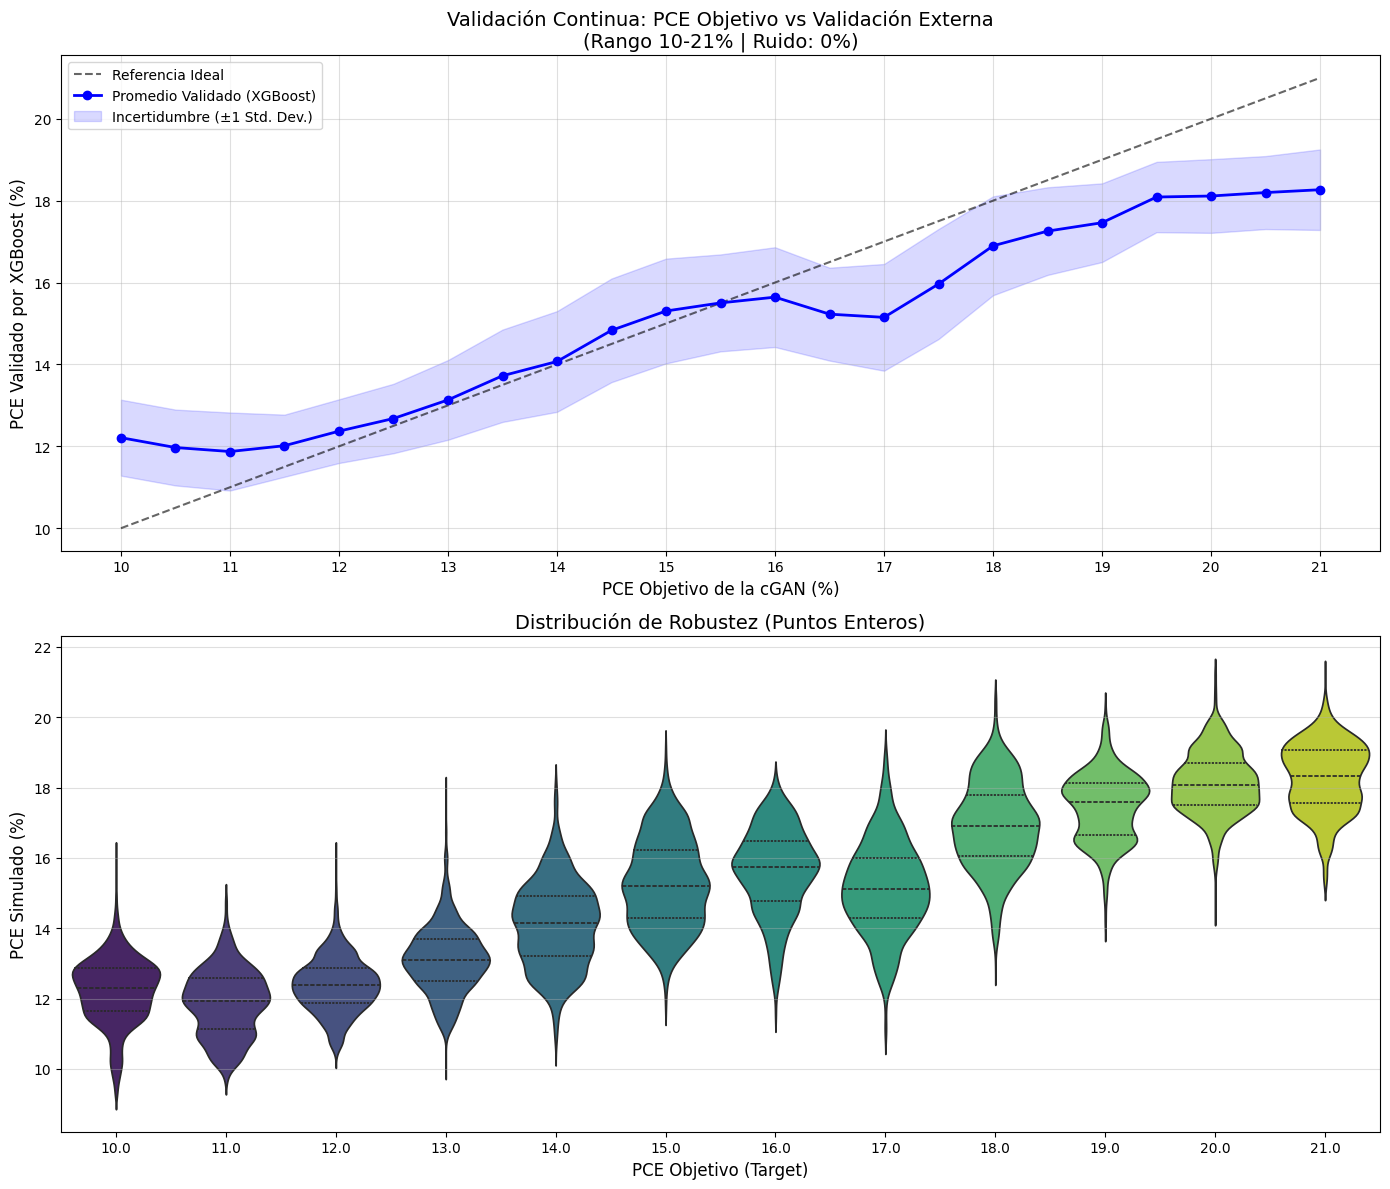


RESUMEN FINAL DE LA VALIDACIÓN CONTINUA
Error Absoluto Medio (MAE) Global: 1.0400%
Correlación (R) Target vs Predicción: 0.9833
 RESULTADO: BUENO PERO CON SESGO. Sigue la tendencia pero con offset.


In [ ]:
# =============================================================================
# VALIDACIÓN DE ROBUSTEZ: MODELO PREDICTIVO (XGBOOST) VS GENERADOR (cGAN)
# VERSIÓN ACTUALIZADA: COMPATIBLE CON ZIP Y RANGO CONTINUO
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile


TARGETS_PCE = np.arange(10.0, 21.1, 0.5)

N_SIMULATIONS = 1000     # Simulaciones por cada dato generado
NOISE_LEVEL = 0       # Nivel de ruido experimental
N_SAMPLES_PER_FILE = 1000 # Cantidad de muestras que generaste por archivo

# Nombre del archivo ZIP que contiene los datasets
ZIP_FILENAME = "datasets_generados_10_to_21.zip"

# Nombres de archivos y modelos
MODEL_PATH = 'Lab_Virtual_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE RECURSOS Y EXTRACCIÓN DE DATOS
# =============================================================================
print("Inicializando carga de modelos y herramientas...")

# A) Cargar Modelo Predictivo (Juez)
if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    print(" Modelo XGBoost y Scaler cargados exitosamente.")
else:
    raise FileNotFoundError(" Error crítico: No se encuentran los archivos .joblib (XGBoost). Súbelos primero.")

# B) Descomprimir Datos Generados
print(f"\nBusacando archivo de datos: {ZIP_FILENAME}...")
if os.path.exists(ZIP_FILENAME):
    print(" Descomprimiendo datasets generados...")
    with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
        zip_ref.extractall(".") # Extraer en la carpeta actual
    print(" Descompresión completada.")
else:
    # Si no está el zip, verificamos si los CSV ya están sueltos (por si acaso)
    sample_csv = f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"
    if not os.path.exists(sample_csv):
        print(f" No se encontró {ZIP_FILENAME} ni los archivos CSV extraídos.")
        print("Asegúrate de haber corrido el Script de Generación Universal primero.")

# Contenedores para resultados globales
results_summary = []
all_simulations_data = []

# =============================================================================
# 2. BUCLE DE VALIDACIÓN POR TARGET
# =============================================================================
print(f"\nIniciando Validación Montecarlo para {len(TARGETS_PCE)} objetivos continuos...")
print(f"Rango: {TARGETS_PCE[0]} -> {TARGETS_PCE[-1]}")
print("-" * 80)
print(f"{'Target (GAN)':<15} | {'Predicción Media (XGB)':<25} | {'Desviación Estándar':<20}")
print("-" * 80)

for target in TARGETS_PCE:
    # 2.1 Construir nombre del archivo (Formato del script de generación)
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        # Es normal que falten algunos si el zip no cubrió todo, pero avisamos
        # print(f"   (Info: {filename} no encontrado, saltando...)")
        continue

    # 2.2 Cargar datos generados por la cGAN
    df_gen = pd.read_csv(filename)

    # 2.3 Preprocesamiento Adaptativo
    try:
        expected_features = scaler.n_features_in_
        total_columns = df_gen.shape[1]

        # Lógica de alineación de columnas (Features vs Target)
        # El archivo generado tiene una columna extra al final "PCE_Target" o "Target"

        # Caso A: El archivo tiene exactamente Features + 1 Target
        if total_columns == expected_features + 1:
            X_gen_base = df_gen.iloc[:, :-1].values

        # Caso B: El archivo tiene Metadata + Features + Target (Estructura antigua)
        elif total_columns >= expected_features + 5:
            X_gen_base = df_gen.iloc[:, 4:-1].values

        # Caso C: Busqueda por conteo desde el final
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_gen_base = df_gen.iloc[:, start_col:-1].values
            else:
                # Si fallan las dimensiones, podría ser que el XGBoost fue entrenado con MENOS columnas
                # que la nueva GAN Universal. Esto es una alerta importante.
                print(f" Error de dimensión en {target}: XGBoost espera {expected_features} cols, Dataset tiene {total_columns-1}.")
                continue

    except Exception as e:
        print(f"Error procesando estructura de columnas en {filename}: {e}")
        continue

    # 2.4 MONTECARLO VECTORIZADO
    n_features = X_gen_base.shape[1]

    # Repetimos cada muestra N_SIMULATIONS veces
    X_repeated = np.repeat(X_gen_base, N_SIMULATIONS, axis=0)

    # Generamos matriz de ruido normal
    noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)

    # Aplicamos perturbación: X_new = X * (1 + noise * level)
    X_noisy = X_repeated * (1 + noise_matrix * NOISE_LEVEL)

    # 2.5 Escalar y Predecir
    X_noisy_scaled = scaler.transform(X_noisy)
    y_pred_noisy = model.predict(X_noisy_scaled)

    # 2.6 Calcular Estadísticas Descriptivas
    mean_pred = np.mean(y_pred_noisy)
    std_pred = np.std(y_pred_noisy)

    # Almacenar resumen estadístico
    results_summary.append({
        'Target_GAN': target,
        'Mean_XGB': mean_pred,
        'Std_XGB': std_pred,
        'Lower_CI': np.percentile(y_pred_noisy, 2.5),
        'Upper_CI': np.percentile(y_pred_noisy, 97.5)
    })

    # Almacenar muestra de datos para visualización (muestreo reducido para gráficos rápidos)
    sample_preds = np.random.choice(y_pred_noisy, size=2000, replace=False)
    for p in sample_preds:
        all_simulations_data.append({'Target': target, 'Prediccion': p}) # Target como numero para plot continuo

    print(f"{target:<15.1f} | {mean_pred:<25.4f} | {std_pred:<20.4f}")

# Convertir a DataFrame
df_results = pd.DataFrame(results_summary)
df_violin = pd.DataFrame(all_simulations_data)

if df_results.empty:
    print(" No se procesaron resultados. Verifica que el ZIP se haya descomprimido correctamente.")
else:
    # =============================================================================
    # 3. VISUALIZACIÓN DE RESULTADOS
    # =============================================================================
    plt.figure(figsize=(14, 12))

    # --- PANEL SUPERIOR: Correlación Lineal (Idealmente debe ser una recta) ---
    plt.subplot(2, 1, 1)
    # Línea ideal (Identidad)
    plt.plot(df_results['Target_GAN'], df_results['Target_GAN'], 'k--', label='Referencia Ideal', alpha=0.6)

    # Línea real (Predicción XGBoost)
    plt.plot(df_results['Target_GAN'], df_results['Mean_XGB'], 'b-o', label='Promedio Validado (XGBoost)', linewidth=2)

    # Intervalo de confianza
    plt.fill_between(df_results['Target_GAN'],
                     df_results['Mean_XGB'] - df_results['Std_XGB'],
                     df_results['Mean_XGB'] + df_results['Std_XGB'],
                     color='blue', alpha=0.15, label='Incertidumbre (±1 Std. Dev.)')

    plt.title(f'Validación Continua: PCE Objetivo vs Validación Externa\n(Rango 10-21% | Ruido: {NOISE_LEVEL*100}%)', fontsize=14)
    plt.ylabel('PCE Validado por XGBoost (%)', fontsize=12)
    plt.xlabel('PCE Objetivo de la cGAN (%)', fontsize=12)
    plt.xticks(np.arange(10, 22, 1)) # Eje X más limpio
    plt.legend()
    plt.grid(True, alpha=0.4)

    # --- PANEL INFERIOR: Distribución de Densidad (Violin Plot) ---
    plt.subplot(2, 1, 2)
    # Para el gráfico de violín, si hay demasiados puntos (ej. cada 0.1), se ve saturado.
    # Filtramos para mostrar solo enteros en el eje X del violin plot para limpieza visual
    df_violin_plot = df_violin[df_violin['Target'].apply(lambda x: x.is_integer())]

    sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")
    plt.title('Distribución de Robustez (Puntos Enteros)', fontsize=14)
    plt.ylabel('PCE Simulado (%)', fontsize=12)
    plt.xlabel('PCE Objetivo (Target)', fontsize=12)
    plt.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # 4. CONCLUSIONES DEL ANÁLISIS
    # =============================================================================
    print("\n" + "="*60)
    print("RESUMEN FINAL DE LA VALIDACIÓN CONTINUA")
    print("="*60)

    # Calcular error absoluto medio (MAE)
    mae_global = np.mean(np.abs(df_results['Target_GAN'] - df_results['Mean_XGB']))
    correlation = df_results['Target_GAN'].corr(df_results['Mean_XGB'])

    print(f"Error Absoluto Medio (MAE) Global: {mae_global:.4f}%")
    print(f"Correlación (R) Target vs Predicción: {correlation:.4f}")

    if mae_global < 1.0 and correlation > 0.9:
        print(" RESULTADO: EXCELENTE. La cGAN ha aprendido la tendencia física continua.")
    elif correlation > 0.8:
        print(" RESULTADO: BUENO PERO CON SESGO. Sigue la tendencia pero con offset.")
    else:
        print(" RESULTADO: FALLO EN TENDENCIA. La cGAN no responde linealmente al objetivo.")

RANDOM FOREST

Inicializando carga de modelos y herramientas...
 Modelo XGBoost y Scaler cargados exitosamente.

Busacando archivo de datos: datasets_generados_10_to_21.zip...
 Descomprimiendo datasets generados...
 Descompresión completada.

Iniciando Validación Montecarlo para 23 objetivos continuos...
Rango: 10.0 -> 21.0
--------------------------------------------------------------------------------
Target (GAN)    | Predicción Media (XGB)    | Desviación Estándar 
--------------------------------------------------------------------------------
10.0            | 12.6336                   | 1.0796              
10.5            | 12.3946                   | 1.0246              
11.0            | 12.4028                   | 0.8681              
11.5            | 12.5555                   | 0.5918              
12.0            | 12.8935                   | 0.5739              
12.5            | 13.1172                   | 0.5457              
13.0            | 13.2321                   | 0.6879      

/tmp/ipykernel_189/551371747.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")


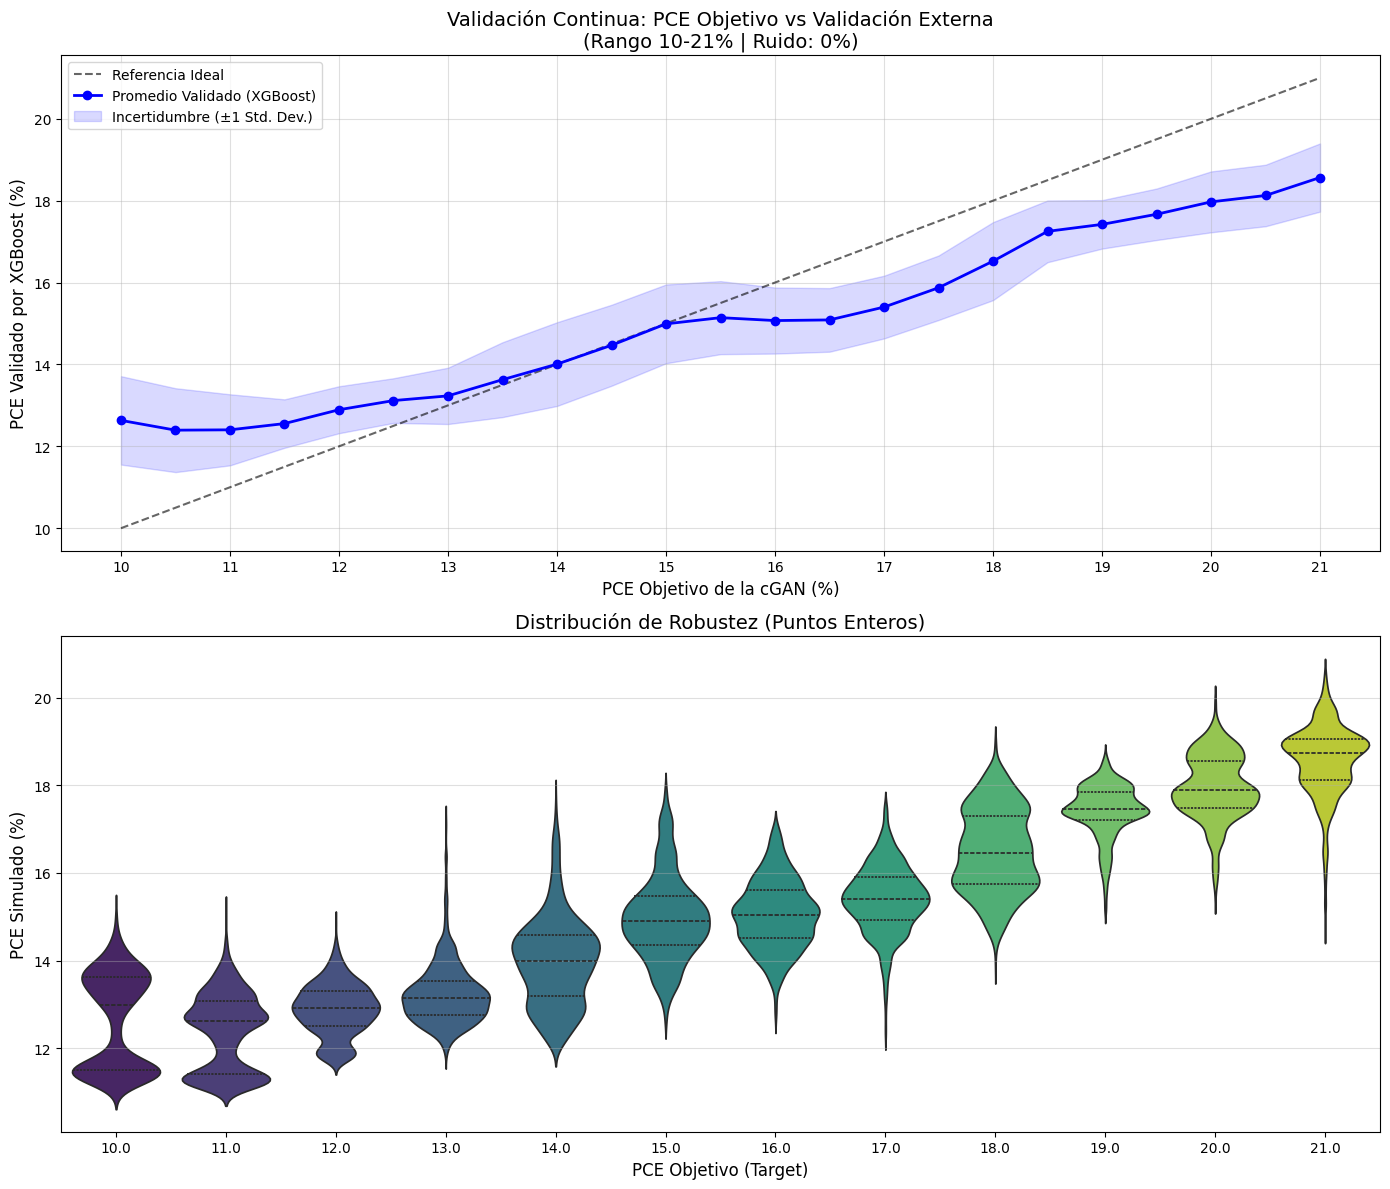


RESUMEN FINAL DE LA VALIDACIÓN CONTINUA
Error Absoluto Medio (MAE) Global: 1.2090%
Correlación (R) Target vs Predicción: 0.9870
 RESULTADO: BUENO PERO CON SESGO. Sigue la tendencia pero con offset.


In [ ]:
# =============================================================================
# VALIDACIÓN DE ROBUSTEZ: MODELO PREDICTIVO (XGBOOST) VS GENERADOR (cGAN)
# VERSIÓN ACTUALIZADA: COMPATIBLE CON ZIP Y RANGO CONTINUO
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile


TARGETS_PCE = np.arange(10.0, 21.1, 0.5)

N_SIMULATIONS = 1000     # Simulaciones por cada dato generado
NOISE_LEVEL = 0       # Nivel de ruido experimental
N_SAMPLES_PER_FILE = 1000 # Cantidad de muestras que generaste por archivo

# Nombre del archivo ZIP que contiene los datasets
ZIP_FILENAME = "datasets_generados_10_to_21.zip"

# Nombres de archivos y modelos
MODEL_PATH = 'Lab_Virtual_RF_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE RECURSOS Y EXTRACCIÓN DE DATOS
# =============================================================================
print("Inicializando carga de modelos y herramientas...")

# A) Cargar Modelo Predictivo (Juez)
if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    print(" Modelo XGBoost y Scaler cargados exitosamente.")
else:
    raise FileNotFoundError(" Error crítico: No se encuentran los archivos .joblib (XGBoost). Súbelos primero.")

# B) Descomprimir Datos Generados
print(f"\nBusacando archivo de datos: {ZIP_FILENAME}...")
if os.path.exists(ZIP_FILENAME):
    print(" Descomprimiendo datasets generados...")
    with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
        zip_ref.extractall(".") # Extraer en la carpeta actual
    print(" Descompresión completada.")
else:
    # Si no está el zip, verificamos si los CSV ya están sueltos (por si acaso)
    sample_csv = f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"
    if not os.path.exists(sample_csv):
        print(f" No se encontró {ZIP_FILENAME} ni los archivos CSV extraídos.")
        print("Asegúrate de haber corrido el Script de Generación Universal primero.")

# Contenedores para resultados globales
results_summary = []
all_simulations_data = []

# =============================================================================
# 2. BUCLE DE VALIDACIÓN POR TARGET
# =============================================================================
print(f"\nIniciando Validación Montecarlo para {len(TARGETS_PCE)} objetivos continuos...")
print(f"Rango: {TARGETS_PCE[0]} -> {TARGETS_PCE[-1]}")
print("-" * 80)
print(f"{'Target (GAN)':<15} | {'Predicción Media (XGB)':<25} | {'Desviación Estándar':<20}")
print("-" * 80)

for target in TARGETS_PCE:
    # 2.1 Construir nombre del archivo (Formato del script de generación)
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        # Es normal que falten algunos si el zip no cubrió todo, pero avisamos
        # print(f"   (Info: {filename} no encontrado, saltando...)")
        continue

    # 2.2 Cargar datos generados por la cGAN
    df_gen = pd.read_csv(filename)

    # 2.3 Preprocesamiento Adaptativo
    try:
        expected_features = scaler.n_features_in_
        total_columns = df_gen.shape[1]

        # Lógica de alineación de columnas (Features vs Target)
        # El archivo generado tiene una columna extra al final "PCE_Target" o "Target"

        # Caso A: El archivo tiene exactamente Features + 1 Target
        if total_columns == expected_features + 1:
            X_gen_base = df_gen.iloc[:, :-1].values

        # Caso B: El archivo tiene Metadata + Features + Target (Estructura antigua)
        elif total_columns >= expected_features + 5:
            X_gen_base = df_gen.iloc[:, 4:-1].values

        # Caso C: Busqueda por conteo desde el final
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_gen_base = df_gen.iloc[:, start_col:-1].values
            else:
                # Si fallan las dimensiones, podría ser que el XGBoost fue entrenado con MENOS columnas
                # que la nueva GAN Universal. Esto es una alerta importante.
                print(f" Error de dimensión en {target}: XGBoost espera {expected_features} cols, Dataset tiene {total_columns-1}.")
                continue

    except Exception as e:
        print(f"Error procesando estructura de columnas en {filename}: {e}")
        continue

    # 2.4 MONTECARLO VECTORIZADO
    n_features = X_gen_base.shape[1]

    # Repetimos cada muestra N_SIMULATIONS veces
    X_repeated = np.repeat(X_gen_base, N_SIMULATIONS, axis=0)

    # Generamos matriz de ruido normal
    noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)

    # Aplicamos perturbación: X_new = X * (1 + noise * level)
    X_noisy = X_repeated * (1 + noise_matrix * NOISE_LEVEL)

    # 2.5 Escalar y Predecir
    X_noisy_scaled = scaler.transform(X_noisy)
    y_pred_noisy = model.predict(X_noisy_scaled)

    # 2.6 Calcular Estadísticas Descriptivas
    mean_pred = np.mean(y_pred_noisy)
    std_pred = np.std(y_pred_noisy)

    # Almacenar resumen estadístico
    results_summary.append({
        'Target_GAN': target,
        'Mean_XGB': mean_pred,
        'Std_XGB': std_pred,
        'Lower_CI': np.percentile(y_pred_noisy, 2.5),
        'Upper_CI': np.percentile(y_pred_noisy, 97.5)
    })

    # Almacenar muestra de datos para visualización (muestreo reducido para gráficos rápidos)
    sample_preds = np.random.choice(y_pred_noisy, size=2000, replace=False)
    for p in sample_preds:
        all_simulations_data.append({'Target': target, 'Prediccion': p}) # Target como numero para plot continuo

    print(f"{target:<15.1f} | {mean_pred:<25.4f} | {std_pred:<20.4f}")

# Convertir a DataFrame
df_results = pd.DataFrame(results_summary)
df_violin = pd.DataFrame(all_simulations_data)

if df_results.empty:
    print(" No se procesaron resultados. Verifica que el ZIP se haya descomprimido correctamente.")
else:
    # =============================================================================
    # 3. VISUALIZACIÓN DE RESULTADOS
    # =============================================================================
    plt.figure(figsize=(14, 12))

    # --- PANEL SUPERIOR: Correlación Lineal (Idealmente debe ser una recta) ---
    plt.subplot(2, 1, 1)
    # Línea ideal (Identidad)
    plt.plot(df_results['Target_GAN'], df_results['Target_GAN'], 'k--', label='Referencia Ideal', alpha=0.6)

    # Línea real (Predicción XGBoost)
    plt.plot(df_results['Target_GAN'], df_results['Mean_XGB'], 'b-o', label='Promedio Validado (XGBoost)', linewidth=2)

    # Intervalo de confianza
    plt.fill_between(df_results['Target_GAN'],
                     df_results['Mean_XGB'] - df_results['Std_XGB'],
                     df_results['Mean_XGB'] + df_results['Std_XGB'],
                     color='blue', alpha=0.15, label='Incertidumbre (±1 Std. Dev.)')

    plt.title(f'Validación Continua: PCE Objetivo vs Validación Externa\n(Rango 10-21% | Ruido: {NOISE_LEVEL*100}%)', fontsize=14)
    plt.ylabel('PCE Validado por XGBoost (%)', fontsize=12)
    plt.xlabel('PCE Objetivo de la cGAN (%)', fontsize=12)
    plt.xticks(np.arange(10, 22, 1)) # Eje X más limpio
    plt.legend()
    plt.grid(True, alpha=0.4)

    # --- PANEL INFERIOR: Distribución de Densidad (Violin Plot) ---
    plt.subplot(2, 1, 2)
    # Para el gráfico de violín, si hay demasiados puntos (ej. cada 0.1), se ve saturado.
    # Filtramos para mostrar solo enteros en el eje X del violin plot para limpieza visual
    df_violin_plot = df_violin[df_violin['Target'].apply(lambda x: x.is_integer())]

    sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")
    plt.title('Distribución de Robustez (Puntos Enteros)', fontsize=14)
    plt.ylabel('PCE Simulado (%)', fontsize=12)
    plt.xlabel('PCE Objetivo (Target)', fontsize=12)
    plt.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # 4. CONCLUSIONES DEL ANÁLISIS
    # =============================================================================
    print("\n" + "="*60)
    print("RESUMEN FINAL DE LA VALIDACIÓN CONTINUA")
    print("="*60)

    # Calcular error absoluto medio (MAE)
    mae_global = np.mean(np.abs(df_results['Target_GAN'] - df_results['Mean_XGB']))
    correlation = df_results['Target_GAN'].corr(df_results['Mean_XGB'])

    print(f"Error Absoluto Medio (MAE) Global: {mae_global:.4f}%")
    print(f"Correlación (R) Target vs Predicción: {correlation:.4f}")

    if mae_global < 1.0 and correlation > 0.9:
        print(" RESULTADO: EXCELENTE. La cGAN ha aprendido la tendencia física continua.")
    elif correlation > 0.8:
        print(" RESULTADO: BUENO PERO CON SESGO. Sigue la tendencia pero con offset.")
    else:
        print(" RESULTADO: FALLO EN TENDENCIA. La cGAN no responde linealmente al objetivo.")

Plot successfully saved as: Montecarlo_Validation_Comparison.png


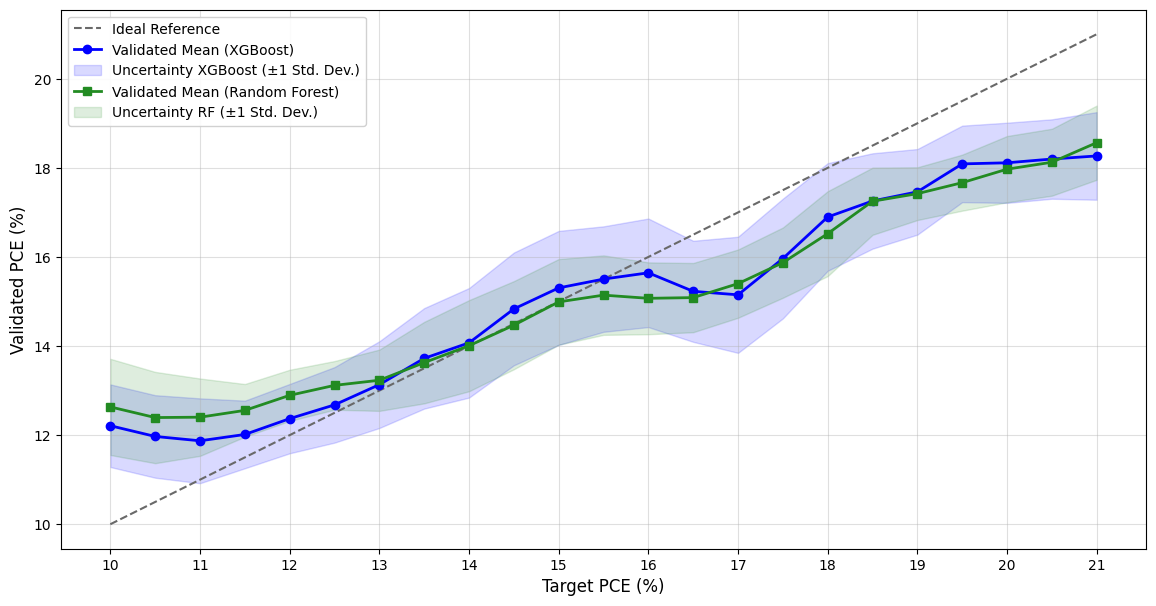

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Definition
targets = np.arange(10.0, 21.5, 0.5)

# XGBoost Data
xgb_mean = np.array([
    12.2112, 11.9704, 11.8729, 12.0149, 12.3703, 12.6793, 13.1335, 13.7235, 14.0721,
    14.8331, 15.3050, 15.5032, 15.6439, 15.2284, 15.1499, 15.9642, 16.8973, 17.2564,
    17.4617, 18.0891, 18.1137, 18.1981, 18.2677
])
xgb_std = np.array([
    0.9272, 0.9263, 0.9525, 0.7588, 0.7781, 0.8478, 0.9735, 1.1281, 1.2297,
    1.2656, 1.2794, 1.1838, 1.2184, 1.1345, 1.3034, 1.3441, 1.2077, 1.0706,
    0.9610, 0.8588, 0.9000, 0.8915, 0.9833
])

# Random Forest Data
rf_mean = np.array([
    12.6336, 12.3946, 12.4028, 12.5555, 12.8935, 13.1172, 13.2321, 13.6279, 14.0077,
    14.4681, 14.9910, 15.1427, 15.0715, 15.0873, 15.4009, 15.8725, 16.5230, 17.2507,
    17.4207, 17.6676, 17.9706, 18.1264, 18.5655
])
rf_std = np.array([
    1.0796, 1.0246, 0.8681, 0.5918, 0.5739, 0.5457, 0.6879, 0.9147, 1.0224,
    0.9893, 0.9619, 0.8919, 0.8062, 0.7768, 0.7661, 0.7882, 0.9526, 0.7539,
    0.5921, 0.6290, 0.7437, 0.7513, 0.8330
])

# 2. Plot Configuration
plt.figure(figsize=(14, 7))

# Ideal Reference Line
plt.plot(targets, targets, '--', color='dimgray', label='Ideal Reference')

# XGBoost Plot
plt.plot(targets, xgb_mean, '-o', color='blue', linewidth=2, label='Validated Mean (XGBoost)')
plt.fill_between(targets, xgb_mean - xgb_std, xgb_mean + xgb_std, color='blue', alpha=0.15, label='Uncertainty XGBoost (±1 Std. Dev.)')

# Random Forest Plot
plt.plot(targets, rf_mean, '-s', color='forestgreen', linewidth=2, label='Validated Mean (Random Forest)')
plt.fill_between(targets, rf_mean - rf_std, rf_mean + rf_std, color='forestgreen', alpha=0.15, label='Uncertainty RF (±1 Std. Dev.)')

# 3. Formatting and Styling
#plt.title('Continuous Validation: Target PCE vs External Validation\n(Range 10-21%)', color='blue', fontsize=14, fontweight='bold')
plt.xlabel('Target PCE (%)', color='black', fontsize=12)
plt.ylabel('Validated PCE (%)', color='black', fontsize=12)

# Set tick colors and define x-axis to show only integer values
integer_ticks = np.arange(10, 22, 1)
plt.xticks(integer_ticks, color='black')
plt.yticks(color='black')

# Grid and Legend
plt.grid(True, linestyle='-', alpha=0.4)
legend = plt.legend(loc='upper left', framealpha=0.9)

# Force all text in the legend to be blue
for text in legend.get_texts():
    text.set_color('black')

# 4. Export as .png and Display Inline
file_name = 'Montecarlo_Validation_Comparison.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"Plot successfully saved as: {file_name}")

# Display the plot directly in the notebook output
plt.show()

# **ROBUSTNESS TESTING OF THE INVERSE DESIGN**
Noise ranging from 0 to 10% was introduced into the Monte Carlo simulation (N=1000 iterations per target) of the virtual laboratory.


⚙️ Inicializando recursos...

📥 Cargando datos base en memoria RAM...
 Datos cargados para 23 objetivos (Targets).

 Iniciando prueba de estrés: 11 niveles de ruido...
-----------------------------------------------------------------
Nivel Ruido (%)      | MAE Global      | Correlación (R)
-----------------------------------------------------------------
0.0                  | 1.0400          | 0.9833         
1.0                  | 1.1046          | 0.9866         
2.0                  | 1.1603          | 0.9898         
3.0                  | 1.2033          | 0.9903         
4.0                  | 1.2397          | 0.9899         
5.0                  | 1.2822          | 0.9892         
6.0                  | 1.3215          | 0.9888         
7.0                  | 1.3560          | 0.9883         
8.0                  | 1.3886          | 0.9879         
9.0                  | 1.4240          | 0.9875         
10.0                 | 1.4594          | 0.9870         


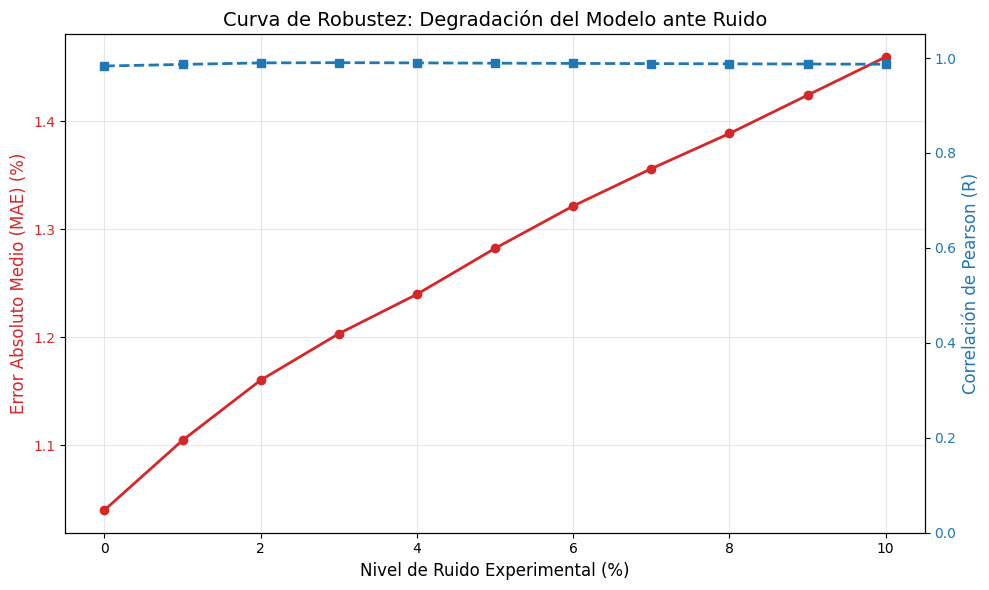


DIAGNÓSTICO DE ROBUSTEZ
MAE Inicial (0% Ruido): 1.0400
MAE Final (10% Ruido): 1.4594
Degradación: +0.4194 puntos de error.
 EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.


In [ ]:
# =============================================================================
# PRUEBA DE ROBUSTEZ CIENTÍFICA: SENSIBILIDAD AL RUIDO (0% - 10%)
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
import zipfile

# --- CONFIGURACIÓN ---
TARGETS_PCE = np.arange(10.0, 21.1, 0.5)
N_SAMPLES_PER_FILE = 1000
N_SIMULATIONS = 1000

# DEFINICIÓN DEL BARRIDO DE RUIDO
# De 0.00 (0%) a 0.10 (10%) en pasos de 0.01 (1%)
NOISE_LEVELS = np.arange(0.00, 0.11, 0.01)

ZIP_FILENAME = "datasets_generados_10_to_21.zip"
MODEL_PATH = 'Lab_Virtual_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE MODELOS Y EXTRACCIÓN
# =============================================================================
print("⚙️ Inicializando recursos...")

if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
else:
    raise FileNotFoundError(" Falta el modelo XGBoost o el Scaler.")

if not os.path.exists(f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"):
    if os.path.exists(ZIP_FILENAME):
        print(" Descomprimiendo datos...")
        with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
            zip_ref.extractall(".")
    else:
        print(" No encuentro ZIP ni CSVs. Asegúrate de tener los datos.")

# =============================================================================
# 2. PRE-CARGA DE DATOS EN MEMORIA (OPTIMIZACIÓN)
# =============================================================================
# Para no leer el disco 11 veces (una por cada nivel de ruido),
# cargamos todos los matrices X base en un diccionario primero.
print(f"\n📥 Cargando datos base en memoria RAM...")

data_cache = {} # Diccionario {target: matriz_X}

for target in TARGETS_PCE:
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        continue # Saltar si falta alguno

    df_gen = pd.read_csv(filename)

    # Lógica de columnas (Tu lógica original adaptada)
    expected_features = scaler.n_features_in_
    total_columns = df_gen.shape[1]

    try:
        if total_columns == expected_features + 1:
            X_base = df_gen.iloc[:, :-1].values
        elif total_columns >= expected_features + 5:
            X_base = df_gen.iloc[:, 4:-1].values
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_base = df_gen.iloc[:, start_col:-1].values
            else:
                continue

        # Guardamos en caché
        data_cache[target] = X_base

    except Exception:
        continue

print(f" Datos cargados para {len(data_cache)} objetivos (Targets).")

# =============================================================================
# 3. BUCLE DE ROBUSTEZ (SWEEP DE RUIDO)
# =============================================================================
print(f"\n Iniciando prueba de estrés: {len(NOISE_LEVELS)} niveles de ruido...")
print("-" * 65)
print(f"{'Nivel Ruido (%)':<20} | {'MAE Global':<15} | {'Correlación (R)':<15}")
print("-" * 65)

robustness_log = []

for noise in NOISE_LEVELS:

    # Listas temporales para este nivel de ruido específico
    targets_curr = []
    preds_curr = []

    for target, X_base in data_cache.items():
        # A) Vectorización Montecarlo
        # Repetimos X para simular variabilidad
        X_repeated = np.repeat(X_base, N_SIMULATIONS // 10, axis=0) # Optimización leve

        # B) Inyección de Ruido
        noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)
        X_noisy = X_repeated * (1 + noise_matrix * noise)

        # C) Predicción
        X_scaled = scaler.transform(X_noisy)
        y_pred = model.predict(X_scaled)

        # Guardamos promedio
        targets_curr.append(target)
        preds_curr.append(np.mean(y_pred))

    # D) Calcular Métricas Globales para este nivel de ruido
    targets_arr = np.array(targets_curr)
    preds_arr = np.array(preds_curr)

    mae = np.mean(np.abs(targets_arr - preds_arr))
    corr = np.corrcoef(targets_arr, preds_arr)[0, 1]

    robustness_log.append({
        'Noise_Pct': noise * 100,
        'MAE': mae,
        'Correlation': corr
    })

    print(f"{noise*100:<20.1f} | {mae:<15.4f} | {corr:<15.4f}")

# =============================================================================
# 4. VISUALIZACIÓN DE LA CURVA DE DEGRADACIÓN
# =============================================================================
df_robustness = pd.DataFrame(robustness_log)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y Izquierdo: MAE (Queremos que sea bajo)
color = 'tab:red'
ax1.set_xlabel('Nivel de Ruido Experimental (%)', fontsize=12)
ax1.set_ylabel('Error Absoluto Medio (MAE) (%)', color=color, fontsize=12)
ax1.plot(df_robustness['Noise_Pct'], df_robustness['MAE'], color=color, marker='o', label='MAE (Error)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Eje Y Derecho: Correlación (Queremos que sea alta)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Correlación de Pearson (R)', color=color, fontsize=12)
ax2.plot(df_robustness['Noise_Pct'], df_robustness['Correlation'], color=color, marker='s', linestyle='--', label='Correlación', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
# Fijar límites para correlación (idealmente cerca de 1)
ax2.set_ylim(0, 1.05)

plt.title('Curva de Robustez: Degradación del Modelo ante Ruido', fontsize=14)
fig.tight_layout()
plt.show()

# =============================================================================
# 5. CONCLUSIÓN AUTOMÁTICA
# =============================================================================
print("\n" + "="*60)
print("DIAGNÓSTICO DE ROBUSTEZ")
print("="*60)

mae_0 = df_robustness.iloc[0]['MAE']
mae_10 = df_robustness.iloc[-1]['MAE']
degradation = mae_10 - mae_0

print(f"MAE Inicial (0% Ruido): {mae_0:.4f}")
print(f"MAE Final (10% Ruido): {mae_10:.4f}")
print(f"Degradación: +{degradation:.4f} puntos de error.")

if degradation < 1.0:
    print(" EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.")
elif degradation < 2.5:
    print(" EL MODELO ES SENSIBLE. El ruido degrada notablemente la precisión.")
else:
    print(" EL MODELO ES INESTABLE ante ruido alto.")

⚙️ Inicializando recursos...

📥 Cargando datos base en memoria RAM...
 Datos cargados para 23 objetivos (Targets).

 Iniciando prueba de estrés: 11 niveles de ruido...
-----------------------------------------------------------------
Nivel Ruido (%)      | MAE Global      | Correlación (R)
-----------------------------------------------------------------
0.0                  | 1.2090          | 0.9870         
1.0                  | 1.2349          | 0.9894         
2.0                  | 1.2864          | 0.9915         
3.0                  | 1.3379          | 0.9929         
4.0                  | 1.3792          | 0.9935         
5.0                  | 1.4163          | 0.9937         
6.0                  | 1.4486          | 0.9937         
7.0                  | 1.4783          | 0.9938         
8.0                  | 1.5096          | 0.9938         
9.0                  | 1.5361          | 0.9938         
10.0                 | 1.5613          | 0.9937         


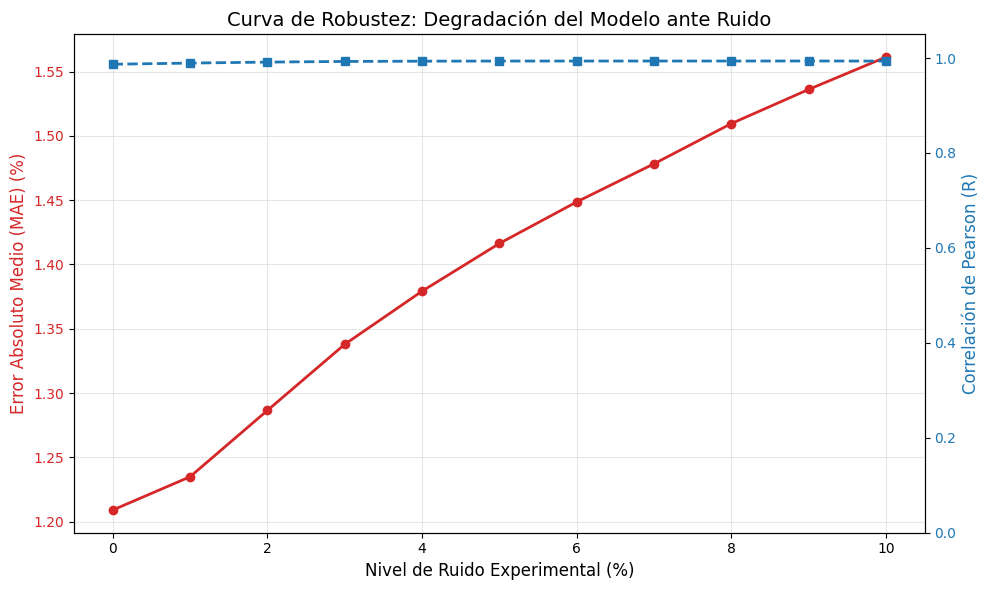


DIAGNÓSTICO DE ROBUSTEZ
MAE Inicial (0% Ruido): 1.2090
MAE Final (10% Ruido): 1.5613
Degradación: +0.3524 puntos de error.
 EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.


In [ ]:
# =============================================================================
# PRUEBA DE ROBUSTEZ CIENTÍFICA: SENSIBILIDAD AL RUIDO (0% - 10%)
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
import zipfile

# --- CONFIGURACIÓN ---
TARGETS_PCE = np.arange(10.0, 21.1, 0.5)
N_SAMPLES_PER_FILE = 1000
N_SIMULATIONS = 1000

# DEFINICIÓN DEL BARRIDO DE RUIDO
# De 0.00 (0%) a 0.10 (10%) en pasos de 0.01 (1%)
NOISE_LEVELS = np.arange(0.00, 0.11, 0.01)

ZIP_FILENAME = "datasets_generados_10_to_21.zip"
MODEL_PATH = 'Lab_Virtual_RF_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE MODELOS Y EXTRACCIÓN
# =============================================================================
print("⚙️ Inicializando recursos...")

if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
else:
    raise FileNotFoundError(" Falta el modelo XGBoost o el Scaler.")

if not os.path.exists(f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"):
    if os.path.exists(ZIP_FILENAME):
        print(" Descomprimiendo datos...")
        with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
            zip_ref.extractall(".")
    else:
        print(" No encuentro ZIP ni CSVs. Asegúrate de tener los datos.")

# =============================================================================
# 2. PRE-CARGA DE DATOS EN MEMORIA (OPTIMIZACIÓN)
# =============================================================================
# Para no leer el disco 11 veces (una por cada nivel de ruido),
# cargamos todos los matrices X base en un diccionario primero.
print(f"\n📥 Cargando datos base en memoria RAM...")

data_cache = {} # Diccionario {target: matriz_X}

for target in TARGETS_PCE:
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        continue # Saltar si falta alguno

    df_gen = pd.read_csv(filename)

    # Lógica de columnas (Tu lógica original adaptada)
    expected_features = scaler.n_features_in_
    total_columns = df_gen.shape[1]

    try:
        if total_columns == expected_features + 1:
            X_base = df_gen.iloc[:, :-1].values
        elif total_columns >= expected_features + 5:
            X_base = df_gen.iloc[:, 4:-1].values
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_base = df_gen.iloc[:, start_col:-1].values
            else:
                continue

        # Guardamos en caché
        data_cache[target] = X_base

    except Exception:
        continue

print(f" Datos cargados para {len(data_cache)} objetivos (Targets).")

# =============================================================================
# 3. BUCLE DE ROBUSTEZ (SWEEP DE RUIDO)
# =============================================================================
print(f"\n Iniciando prueba de estrés: {len(NOISE_LEVELS)} niveles de ruido...")
print("-" * 65)
print(f"{'Nivel Ruido (%)':<20} | {'MAE Global':<15} | {'Correlación (R)':<15}")
print("-" * 65)

robustness_log = []

for noise in NOISE_LEVELS:

    # Listas temporales para este nivel de ruido específico
    targets_curr = []
    preds_curr = []

    for target, X_base in data_cache.items():
        # A) Vectorización Montecarlo
        # Repetimos X para simular variabilidad
        X_repeated = np.repeat(X_base, N_SIMULATIONS // 10, axis=0) # Optimización leve

        # B) Inyección de Ruido
        noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)
        X_noisy = X_repeated * (1 + noise_matrix * noise)

        # C) Predicción
        X_scaled = scaler.transform(X_noisy)
        y_pred = model.predict(X_scaled)

        # Guardamos promedio
        targets_curr.append(target)
        preds_curr.append(np.mean(y_pred))

    # D) Calcular Métricas Globales para este nivel de ruido
    targets_arr = np.array(targets_curr)
    preds_arr = np.array(preds_curr)

    mae = np.mean(np.abs(targets_arr - preds_arr))
    corr = np.corrcoef(targets_arr, preds_arr)[0, 1]

    robustness_log.append({
        'Noise_Pct': noise * 100,
        'MAE': mae,
        'Correlation': corr
    })

    print(f"{noise*100:<20.1f} | {mae:<15.4f} | {corr:<15.4f}")

# =============================================================================
# 4. VISUALIZACIÓN DE LA CURVA DE DEGRADACIÓN
# =============================================================================
df_robustness = pd.DataFrame(robustness_log)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y Izquierdo: MAE (Queremos que sea bajo)
color = 'tab:red'
ax1.set_xlabel('Nivel de Ruido Experimental (%)', fontsize=12)
ax1.set_ylabel('Error Absoluto Medio (MAE) (%)', color=color, fontsize=12)
ax1.plot(df_robustness['Noise_Pct'], df_robustness['MAE'], color=color, marker='o', label='MAE (Error)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Eje Y Derecho: Correlación (Queremos que sea alta)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Correlación de Pearson (R)', color=color, fontsize=12)
ax2.plot(df_robustness['Noise_Pct'], df_robustness['Correlation'], color=color, marker='s', linestyle='--', label='Correlación', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
# Fijar límites para correlación (idealmente cerca de 1)
ax2.set_ylim(0, 1.05)

plt.title('Curva de Robustez: Degradación del Modelo ante Ruido', fontsize=14)
fig.tight_layout()
plt.show()

# =============================================================================
# 5. CONCLUSIÓN AUTOMÁTICA
# =============================================================================
print("\n" + "="*60)
print("DIAGNÓSTICO DE ROBUSTEZ")
print("="*60)

mae_0 = df_robustness.iloc[0]['MAE']
mae_10 = df_robustness.iloc[-1]['MAE']
degradation = mae_10 - mae_0

print(f"MAE Inicial (0% Ruido): {mae_0:.4f}")
print(f"MAE Final (10% Ruido): {mae_10:.4f}")
print(f"Degradación: +{degradation:.4f} puntos de error.")

if degradation < 1.0:
    print(" EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.")
elif degradation < 2.5:
    print(" EL MODELO ES SENSIBLE. El ruido degrada notablemente la precisión.")
else:
    print(" EL MODELO ES INESTABLE ante ruido alto.")

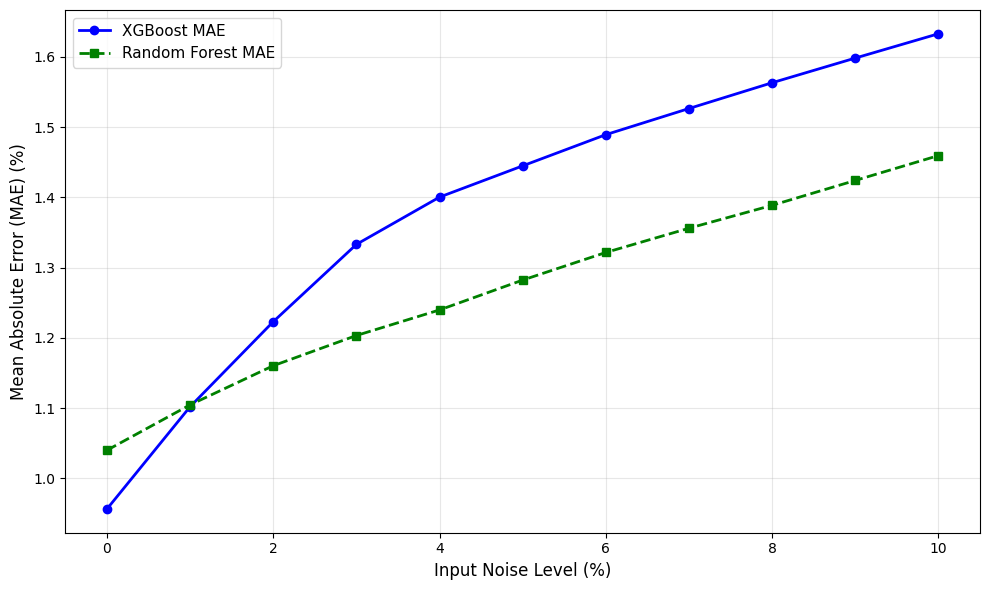

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATOS DE VALIDACIÓN DE ROBUSTEZ (MAE vs Noise)
# =============================================================================

# Datos para XGBoost
data_xgb = {
    'Noise_Pct': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
    'MAE': [0.9564, 1.1020, 1.2230, 1.3330, 1.4003, 1.4448, 1.4892, 1.5264, 1.5631, 1.5982, 1.6328]
}
df_xgb = pd.DataFrame(data_xgb)

# Datos para Random Forest
data_rf = {
    'Noise_Pct': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
    'MAE': [1.0400, 1.1046, 1.1603, 1.2033, 1.2397, 1.2822, 1.3215, 1.3560, 1.3886, 1.4240, 1.4594]
}
df_rf = pd.DataFrame(data_rf)

# =============================================================================
# 2. VISUALIZACIÓN COMPARATIVA DE LA CURVA DE DEGRADACIÓN
# =============================================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

# Configuración de los ejes
ax1.set_xlabel('Input Noise Level (%)', fontsize=12)
ax1.set_ylabel('Mean Absolute Error (MAE) (%)', fontsize=12)

# Graficar XGBoost (Azul claro con círculos)
ax1.plot(df_xgb['Noise_Pct'], df_xgb['MAE'],
         color='blue', marker='o', label='XGBoost MAE', linewidth=2)

# Graficar Random Forest (Azul oscuro con cuadrados y línea punteada)
ax1.plot(df_rf['Noise_Pct'], df_rf['MAE'],
         color='green', marker='s', linestyle='--', label='Random Forest MAE', linewidth=2)

# Ajustes estéticos de la grilla y el eje
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Añadir la leyenda para identificar los modelos
ax1.legend(loc='upper left', fontsize=11)

# Título de la gráfica en inglés
#plt.title('Robustness Curve: Model Degradation vs Noise Comparison', fontsize=14, fontweight='bold')

# Ajustar diseño y mostrar
fig.tight_layout()
plt.show()